In [1]:
import nilearn
from nilearn import datasets, plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import MultiNiftiLabelsMasker
import os
import requests
import csv
import pandas as pd
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import scipy
from scipy.stats import multivariate_normal
from scipy.spatial.distance import pdist, squareform
from networkx.drawing.nx_agraph import graphviz_layout
from sklearn.metrics.cluster import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.sparse.csgraph import minimum_spanning_tree
from collections import deque, defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
import collections
from collections import defaultdict, deque
import copy
from scipy import stats
import seaborn as sns
from networkx import graph_edit_distance


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


## **Load Data**

In [14]:
# set the working directory to fmri_connectivity_trees root directory
home_base_dir = '/Users/aj/dmello_lab/fmri_connectivity_trees' # directory where repository lives at home computer
lab_base_dir = '/Users/ajjain/Downloads/Code/fmri_connectivity_trees' # directory where repository lives at lab computer
utd_base_dir = '/mfs/io/groups/dmello/projects/dynamric/fmri_connectivity_trees'
biohpc_base_dir = '/project/greencenter/Lin_lab/s229618/fmri_connectivity_trees'

# set base directory depending on where the code is being run
base_dir = home_base_dir if os.path.exists(home_base_dir) else lab_base_dir
base_dir = utd_base_dir if os.path.exists(utd_base_dir) else base_dir
base_dir = biohpc_base_dir if os.path.exists(biohpc_base_dir) else base_dir


# get schaefer
# schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17, resolution_mm=1, data_dir=None, base_url=None, resume=True, verbose=1)
# schaefer_coords = plotting.find_parcellation_cut_coords(labels_img=schaefer.maps)

subjects = [
            'MSC01', 
            'MSC02',
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            'MSC09',
            'MSC10'
            ]

sessions = [
    'func01', 
    'func02', 
    'func03', 
    'func04', 
    'func05', 
    'func06', 
    'func07', 
    'func08', 
    'func09', 
    'func10'
    ]
ids = ['rest']
# motor_ids = ['motor_run-01', 'motor_run-02']
atlas = 'glasser360_SUIT'
atlas_subdir = 'glasser360_SUIT'

# get glasser labels
file_path = f'{base_dir}/atlases/glasser360/glasser360NodeNames.txt'
with open(file_path, 'r') as file:
    glasser_labels = file.readlines()

temp = []
for label in glasser_labels:    
    label = label.strip()
    # reform to match region dataframe below
    components = label.split('_')
    temp.append(components[1] + '_' + components[0][0])
   
glasser_labels = temp

# get glasser region list
glasser_region_list = pd.read_csv(f'{base_dir}/atlases/glasser360/HCP-MMP1_UniqueRegionList.csv')


# get suit labels
suit_labels = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.tsv', sep='\t')
suit_table = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.csv', sep='\t')

# # get Thalamus labels
# thalamus_labels = pd.read_csv(f'{base_dir}/atlases/Thalamus/ThalamusProbs.MNIsymSpace.names.txt', sep=',', header=None)[1]

# # get Brainstem labels
# brainstem_labels = pd.read_csv(f'{base_dir}/atlases/Brainstem/BrainstemProbs.MNIsymSpace.names.txt', sep=',', header=None)[1]


glasser_coords = []
for row in glasser_region_list.iterrows():
    glasser_coords.append([row[1]['x-cog'], row[1]['y-cog'], row[1]['z-cog']])

# all labels
all_labels = glasser_labels + suit_labels['name'].to_list()[:-2] + ['left_global', 'right_global']

glasser_cort_regions = np.unique(glasser_region_list['cortex'])

In [15]:
glasser_cort_regions

array(['Anterior_Cingulate_and_Medial_Prefrontal', 'Auditory_Association',
       'Dorsal_Stream_Visual', 'Dorsolateral_Prefrontal',
       'Early_Auditory', 'Early_Visual', 'Inferior_Frontal',
       'Inferior_Parietal', 'Insular_and_Frontal_Opercular',
       'Lateral_Temporal', 'MT+_Complex_and_Neighboring_Visual_Areas',
       'Medial_Temporal', 'Orbital_and_Polar_Frontal',
       'Paracentral_Lobular_and_Mid_Cingulate', 'Posterior_Cingulate',
       'Posterior_Opercular', 'Premotor', 'Primary_Visual',
       'Somatosensory_and_Motor', 'Superior_Parietal',
       'Temporo-Parieto-Occipital_Junction',
       'Temporo-Parieto_Occipital_Junction', 'Ventral_Stream_Visual'],
      dtype=object)

In [16]:
# thalamus_regions.sort()
# thalamus_regions = [[region] for region in thalamus_regions]

# thalamus_regions
# with open(f'/Users/ajjain/Downloads/Code/fmri_connectivity_trees/atlases/MorelAtlasMNI152/thalamus_regions', 'w', newline='') as csvfile:
#     csv_writer = csv.writer(csvfile)
#     csv_writer.writerows(thalamus_regions)

In [17]:
thalamus_regions = []

with open(f'{base_dir}/atlases/MorelAtlasMNI152/thalamus_regions', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    for row in reader:
        thalamus_regions.append(row[0])

thalamus_regions

['left_AD',
 'left_AM',
 'left_AV',
 'left_CL',
 'left_CM',
 'left_CeM',
 'left_Hb',
 'left_LD',
 'left_LGNmc',
 'left_LGNpc',
 'left_LP',
 'left_Li',
 'left_MAX_VOLUME',
 'left_MDmc',
 'left_MDpc',
 'left_MGN',
 'left_MV',
 'left_Pf',
 'left_Po',
 'left_PuA',
 'left_PuI',
 'left_PuL',
 'left_PuM',
 'left_Pv',
 'left_RN',
 'left_SG',
 'left_STh',
 'left_VAmc',
 'left_VApc',
 'left_VLa',
 'left_VLpd',
 'left_VLpv',
 'left_VM',
 'left_VPI',
 'left_VPLa',
 'left_VPLp',
 'left_VPM',
 'left_global',
 'left_mtt',
 'left_sPf',
 'left_thalamus_body',
 'right_AD',
 'right_AM',
 'right_AV',
 'right_CL',
 'right_CM',
 'right_CeM',
 'right_Hb',
 'right_LD',
 'right_LGNmc',
 'right_LGNpc',
 'right_LP',
 'right_Li',
 'right_MAX_VOLUME',
 'right_MDmc',
 'right_MDpc',
 'right_MGN',
 'right_MV',
 'right_Pf',
 'right_Po',
 'right_PuA',
 'right_PuI',
 'right_PuL',
 'right_PuM',
 'right_RN',
 'right_SG',
 'right_STh',
 'right_VAmc',
 'right_VApc',
 'right_VLa',
 'right_VLpd',
 'right_VLpv',
 'right_VM',
 

In [18]:
thalamus_regions[37]

'left_global'

In [19]:
thalamus_regions[80]

'right_thalamus_body'

In [20]:
def load_data(subjects=subjects, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=100, other_suffix=''):
    """
    Save the covariance matrix to a CSV file.
    """
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        if skl:
            file_name = f'{task}_skl_{num_bins}bins'
        else:
            file_name = f'{task}_{num_bins}bins'
        if other_suffix != '':
            file_name += f'{other_suffix}'

        data[subject] = torch.from_numpy(np.load(f'{data_path}/{file_name}.npy'))
    return data

In [21]:
# subjects = [
#             'MSC01', 
#             'MSC02',
#             'MSC03',
#             'MSC04',
#             'MSC05', 
#             'MSC06',
#             'MSC07', 
#             'MSC08',
#             'MSC09',
#             'MSC10'
#             ]

# task = 'rest'
# num_bins = 100
# other_suffix = 'func-01-10' # temporary suffix I accidentally added but this is all sessions
# atlas = 'glasser360_SUIT'
# atlas_subdir = 'glasser360_SUIT'

# mi_gs = {}
# mi_joint_probs_gs = {}
# product_of_marginals_gs = {}
# entropies_gs = {}

# mi_gs[num_bins] = load_data(subjects=subjects, measure="mutual_information", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
# mi_joint_probs_gs[num_bins] = load_data(subjects=subjects, measure="joint_probs", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
# product_of_marginals_gs[num_bins] = load_data(subjects=subjects, measure="product_of_marginals", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
# entropies_gs[num_bins] = load_data(subjects=subjects, measure="entropies", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)

In [22]:
subjects = [
            'MSC01', 
            # 'MSC02',
            # 'MSC03',
            'MSC04',
            # 'MSC05', 
            # 'MSC06',
            'MSC07', 
            # 'MSC08',
            'MSC09',
            # 'MSC10'
            ]

atlas = 'glasser360_SUIT_Thalamus'
atlas_subdir = 'glasser360_SUIT_Thalamus'

mi_gst = {}
mi_joint_probs_gst = {}
product_of_marginals_gst = {}
entropies_gst = {}
other_suffix = 'func-01-10'
num_bins = 100
task = 'rest'

mi_gst[num_bins] = load_data(subjects=subjects, measure="mutual_information", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
mi_joint_probs_gst[num_bins] = load_data(subjects=subjects, measure="joint_probs", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
product_of_marginals_gst[num_bins] = load_data(subjects=subjects, measure="product_of_marginals", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
entropies_gst[num_bins] = load_data(subjects=subjects, measure="entropies", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)

In [23]:
mi_gst[100]['MSC01'].shape

torch.Size([394, 394])

In [24]:
entropies_gst[100]['MSC01']

# difference in entropy, exponential of that difference tells u how many more states there are in voxel of one person vs. another

tensor([2.9811, 2.9341, 2.9780, 2.9841, 2.9770, 2.9675, 2.9807, 2.9673, 2.9523,
        2.9654, 2.9770, 2.9791, 2.9852, 2.9810, 2.9784, 2.9796, 2.9686, 2.9588,
        2.9536, 2.9777, 2.9710, 2.9772, 2.9753, 2.9696, 2.9789, 2.9685, 2.9855,
        2.9653, 2.9850, 2.9821, 2.9714, 2.9759, 2.9795, 2.9791, 2.9742, 2.9770,
        2.9603, 2.9615, 2.9640, 2.9471, 2.9724, 2.9608, 2.9684, 2.9685, 2.9760,
        2.9827, 2.9754, 2.9759, 2.9704, 2.9726, 2.9759, 2.9690, 2.9753, 2.9767,
        2.9652, 2.9607, 2.9612, 2.9668, 2.9648, 2.9612, 2.9790, 2.9751, 2.9679,
        2.9712, 2.9728, 2.9844, 2.9802, 2.9831, 2.9709, 2.9777, 2.9802, 2.9529,
        2.9800, 2.9733, 2.9843, 2.9666, 2.9765, 2.9637, 2.9767, 2.9742, 2.9779,
        2.9716, 2.9797, 2.9760, 2.9795, 2.9800, 2.9742, 2.9719, 2.9850, 2.9830,
        2.9792, 2.9735, 2.9726, 2.9671, 2.9698, 2.9726, 2.9836, 2.9826, 2.9839,
        2.9850, 2.9745, 2.9561, 2.9534, 2.9578, 2.9590, 2.9243, 2.9385, 2.9563,
        2.9286, 2.9068, 2.9650, 2.9373, 

## **Subject entropy diff**

In [15]:
subjects = [
            'MSC01', 
            # 'MSC02',
            # 'MSC03',
            'MSC04',
            # 'MSC05', 
            # 'MSC06',
            'MSC07', 
            # 'MSC08',
            'MSC09',
            # 'MSC10'
            ]

entropy_data = np.zeros((len(subjects), len(entropies_gst[100][subjects[0]].flatten())))
for i in range(len(subjects)):
    entropy_data[i, :] = entropies_gst[100][subjects[i]].flatten().numpy()


/var/folders/cf/4z622f6j29d4qx7rzj6l433m0000gp/T/ipykernel_71269/743227159.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([entropy_data[i, :] for i in range(n_subjects)],


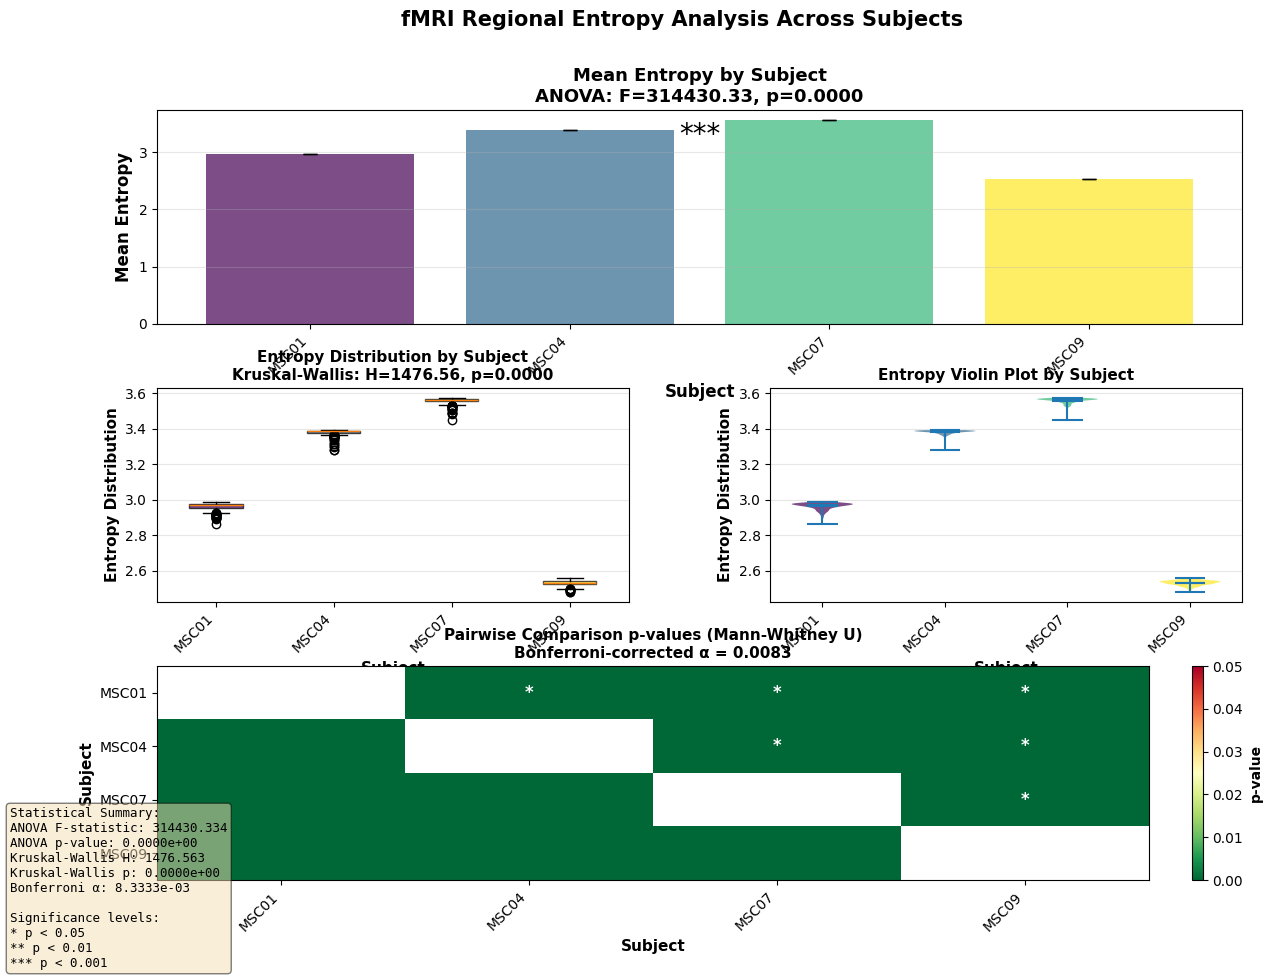

STATISTICAL ANALYSIS SUMMARY

1. One-Way ANOVA
   F-statistic: 314430.3343
   p-value: 0.0000e+00
   Significant: Yes

2. Kruskal-Wallis Test (non-parametric)
   H-statistic: 1476.5631
   p-value: 0.0000e+00
   Significant: Yes

3. Pairwise Comparisons (Mann-Whitney U)
   Total comparisons: 6
   Bonferroni-corrected α: 8.3333e-03
   Significant pairs: 6
      MSC01 vs MSC04: p = 2.2181e-130
      MSC01 vs MSC07: p = 2.2181e-130
      MSC01 vs MSC09: p = 2.2181e-130
      MSC04 vs MSC07: p = 2.2181e-130
      MSC04 vs MSC09: p = 2.2181e-130
      MSC07 vs MSC09: p = 2.2181e-130



In [16]:
n_subjects = len(subjects)
subject_labels = subjects

# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
std_entropy = np.std(entropy_data, axis=1)
sem_entropy = stats.sem(entropy_data, axis=1)

# Perform statistical tests
# 1. One-way ANOVA to test if there are significant differences between subjects
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# 2. Kruskal-Wallis test (non-parametric alternative)
h_stat, p_value_kw = stats.kruskal(*[entropy_data[i, :] for i in range(n_subjects)])

# 3. Post-hoc pairwise comparisons (Wilcoxon with Bonferroni correction)
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

# Create figure with multiple subplots
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Bar plot with error bars
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(n_subjects)
bars = ax1.bar(x_pos, mean_entropy, yerr=sem_entropy, capsize=5, 
               alpha=0.7, color=plt.cm.viridis(np.linspace(0, 1, n_subjects)))
ax1.set_xlabel('Subject', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Entropy', fontsize=12, fontweight='bold')
ax1.set_title(f'Mean Entropy by Subject\nANOVA: F={f_stat:.2f}, p={p_value_anova:.4f}', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(subject_labels, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add significance stars if ANOVA is significant
if p_value_anova < 0.001:
    ax1.text(0.5, 0.95, '***', transform=ax1.transAxes, 
             fontsize=20, ha='center', va='top')
elif p_value_anova < 0.01:
    ax1.text(0.5, 0.95, '**', transform=ax1.transAxes, 
             fontsize=20, ha='center', va='top')
elif p_value_anova < 0.05:
    ax1.text(0.5, 0.95, '*', transform=ax1.transAxes, 
             fontsize=20, ha='center', va='top')

# 2. Box plot
ax2 = fig.add_subplot(gs[1, 0])
bp = ax2.boxplot([entropy_data[i, :] for i in range(n_subjects)],
                  labels=subject_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0, 1, n_subjects))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax2.set_ylabel('Entropy Distribution', fontsize=11, fontweight='bold')
ax2.set_title(f'Entropy Distribution by Subject\nKruskal-Wallis: H={h_stat:.2f}, p={p_value_kw:.4f}', 
              fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# 3. Violin plot
ax3 = fig.add_subplot(gs[1, 1])
parts = ax3.violinplot([entropy_data[i, :] for i in range(n_subjects)],
                        positions=range(n_subjects), showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], plt.cm.viridis(np.linspace(0, 1, n_subjects))):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax3.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax3.set_ylabel('Entropy Distribution', fontsize=11, fontweight='bold')
ax3.set_title('Entropy Violin Plot by Subject', fontsize=11, fontweight='bold')
ax3.set_xticks(range(n_subjects))
ax3.set_xticklabels(subject_labels, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Heatmap of pairwise comparisons
ax4 = fig.add_subplot(gs[2, :])
pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Mask diagonal and apply Bonferroni correction for visualization
pairwise_p_masked = np.ma.masked_where(np.eye(n_subjects, dtype=bool), pairwise_p)
im = ax4.imshow(pairwise_p_masked, cmap='RdYlGn_r', aspect='auto', 
                vmin=0, vmax=0.05, interpolation='nearest')
ax4.set_xticks(range(n_subjects))
ax4.set_yticks(range(n_subjects))
ax4.set_xticklabels(subject_labels, rotation=45, ha='right')
ax4.set_yticklabels(subject_labels)
ax4.set_title(f'Pairwise Comparison p-values (Mann-Whitney U)\nBonferroni-corrected α = {bonferroni_alpha:.4f}', 
              fontsize=11, fontweight='bold')
ax4.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax4.set_ylabel('Subject', fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
cbar.set_label('p-value', fontsize=10, fontweight='bold')

# Add asterisks for significant comparisons
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            ax4.text(j, i, '*', ha='center', va='center', 
                    color='white', fontsize=12, fontweight='bold')

# Add overall statistics text box
stats_text = f"""Statistical Summary:
ANOVA F-statistic: {f_stat:.3f}
ANOVA p-value: {p_value_anova:.4e}
Kruskal-Wallis H: {h_stat:.3f}
Kruskal-Wallis p: {p_value_kw:.4e}
Bonferroni α: {bonferroni_alpha:.4e}

Significance levels:
* p < 0.05
** p < 0.01
*** p < 0.001"""

fig.text(0.02, 0.02, stats_text, fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         verticalalignment='bottom', family='monospace')

plt.suptitle('fMRI Regional Entropy Analysis Across Subjects', 
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('entropy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("="*60)
print("STATISTICAL ANALYSIS SUMMARY")
print("="*60)
print(f"\n1. One-Way ANOVA")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   p-value: {p_value_anova:.4e}")
print(f"   Significant: {'Yes' if p_value_anova < 0.05 else 'No'}")

print(f"\n2. Kruskal-Wallis Test (non-parametric)")
print(f"   H-statistic: {h_stat:.4f}")
print(f"   p-value: {p_value_kw:.4e}")
print(f"   Significant: {'Yes' if p_value_kw < 0.05 else 'No'}")

print(f"\n3. Pairwise Comparisons (Mann-Whitney U)")
print(f"   Total comparisons: {n_comparisons}")
print(f"   Bonferroni-corrected α: {bonferroni_alpha:.4e}")

sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((subject_labels[i], subject_labels[j], pairwise_p[i, j]))

if sig_pairs:
    print(f"   Significant pairs: {len(sig_pairs)}")
    for s1, s2, p in sig_pairs:
        print(f"      {s1} vs {s2}: p = {p:.4e}")
else:
    print(f"   No significant pairwise differences after correction")

print("\n" + "="*60)

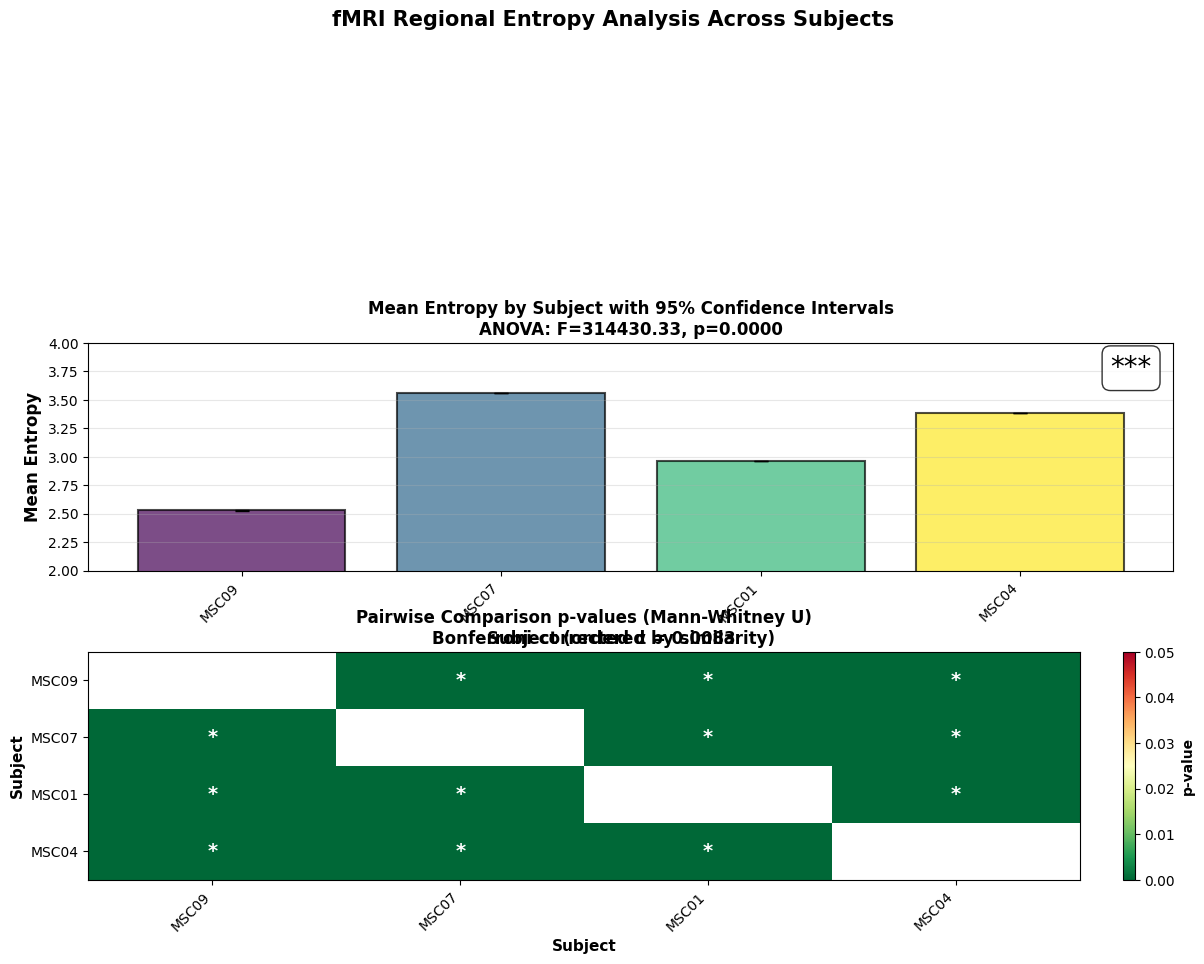

STATISTICAL ANALYSIS SUMMARY

1. One-Way ANOVA
   F-statistic: 314430.3343
   p-value: 0.0000e+00
   Significant: Yes

2. 95% Confidence Intervals
   Calculated using t-distribution with df=393

3. Pairwise Comparisons (Mann-Whitney U)
   Total comparisons: 6
   Bonferroni-corrected α: 8.3333e-03
   Significant pairs: 6
      MSC01 vs MSC04: p = 2.2181e-130
      MSC01 vs MSC07: p = 2.2181e-130
      MSC01 vs MSC09: p = 2.2181e-130
      MSC04 vs MSC07: p = 2.2181e-130
      MSC04 vs MSC09: p = 2.2181e-130
      MSC07 vs MSC09: p = 2.2181e-130



In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

n_regions = len(entropy_data[0, :])

# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
std_entropy = np.std(entropy_data, axis=1)
sem_entropy = stats.sem(entropy_data, axis=1)

# Calculate 95% confidence intervals
confidence_level = 0.95
degrees_freedom = n_regions - 1
t_value = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
ci_entropy = t_value * sem_entropy

# Perform statistical tests
# One-way ANOVA to test if there are significant differences between subjects
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# Post-hoc pairwise comparisons (Wilcoxon with Bonferroni correction)
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

# Create pairwise distance matrix based on p-values
pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Create distance matrix for hierarchical clustering (convert p-values to distances)
# Use -log10(p-value) so that smaller p-values = larger distances = more different
distance_matrix = -np.log10(pairwise_p + 1e-10)  # Add small value to avoid log(0)
np.fill_diagonal(distance_matrix, 0)

# Perform hierarchical clustering
# Convert to condensed distance matrix for linkage
from scipy.spatial.distance import squareform
condensed_dist = squareform(distance_matrix)
linkage_matrix = linkage(condensed_dist, method='average')

# Create figure with adjusted layout
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 1, hspace=0.4, height_ratios=[1, 1.5, 1.5])


# 2. Bar plot with 95% confidence intervals
ax2 = fig.add_subplot(gs[1])
x_pos = np.arange(n_subjects)
ax2.set_ylim(2, 4)

# Get dendrogram leaf order to sort subjects by similarity
dend = dendrogram(linkage_matrix, no_plot=True)
leaf_order = dend['leaves']
sorted_labels = [subject_labels[i] for i in leaf_order]
sorted_means = mean_entropy[leaf_order]
sorted_ci = ci_entropy[leaf_order]

bars = ax2.bar(x_pos, sorted_means, yerr=sorted_ci, capsize=5, 
               alpha=0.7, color=plt.cm.viridis(np.linspace(0, 1, n_subjects)),
               edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Subject (ordered by similarity)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Entropy', fontsize=12, fontweight='bold')
ax2.set_title(f'Mean Entropy by Subject with 95% Confidence Intervals\nANOVA: F={f_stat:.2f}, p={p_value_anova:.4f}', 
              fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add significance notation
if p_value_anova < 0.001:
    sig_text = '***'
elif p_value_anova < 0.01:
    sig_text = '**'
elif p_value_anova < 0.05:
    sig_text = '*'
else:
    sig_text = 'ns'
ax2.text(0.98, 0.95, sig_text, transform=ax2.transAxes, 
         fontsize=20, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Heatmap of pairwise comparisons (reordered by dendrogram)
ax3 = fig.add_subplot(gs[2])

# Reorder matrix according to dendrogram
pairwise_p_reordered = pairwise_p[leaf_order, :][:, leaf_order]

# Mask diagonal
pairwise_p_masked = np.ma.masked_where(np.eye(n_subjects, dtype=bool), pairwise_p_reordered)
im = ax3.imshow(pairwise_p_masked, cmap='RdYlGn_r', aspect='auto', 
                vmin=0, vmax=0.05, interpolation='nearest')
ax3.set_xticks(range(n_subjects))
ax3.set_yticks(range(n_subjects))
ax3.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax3.set_yticklabels(sorted_labels)
ax3.set_title(f'Pairwise Comparison p-values (Mann-Whitney U)\nBonferroni-corrected α = {bonferroni_alpha:.4f}', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax3.set_ylabel('Subject', fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('p-value', fontsize=10, fontweight='bold')

# Add asterisks for significant comparisons after Bonferroni correction
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p_reordered[i, j] < bonferroni_alpha:
            ax3.text(j, i, '*', ha='center', va='center', 
                    color='white', fontsize=14, fontweight='bold')
            ax3.text(i, j, '*', ha='center', va='center', 
                    color='white', fontsize=14, fontweight='bold')

plt.suptitle('fMRI Regional Entropy Analysis Across Subjects', 
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('entropy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("="*60)
print("STATISTICAL ANALYSIS SUMMARY")
print("="*60)
print(f"\n1. One-Way ANOVA")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   p-value: {p_value_anova:.4e}")
print(f"   Significant: {'Yes' if p_value_anova < 0.05 else 'No'}")

print(f"\n2. 95% Confidence Intervals")
print(f"   Calculated using t-distribution with df={degrees_freedom}")

print(f"\n3. Pairwise Comparisons (Mann-Whitney U)")
print(f"   Total comparisons: {n_comparisons}")
print(f"   Bonferroni-corrected α: {bonferroni_alpha:.4e}")

sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((subject_labels[i], subject_labels[j], pairwise_p[i, j]))

if sig_pairs:
    print(f"   Significant pairs: {len(sig_pairs)}")
    for s1, s2, p in sig_pairs:
        print(f"      {s1} vs {s2}: p = {p:.4e}")
else:
    print(f"   No significant pairwise differences after correction")

print("\n" + "="*60)

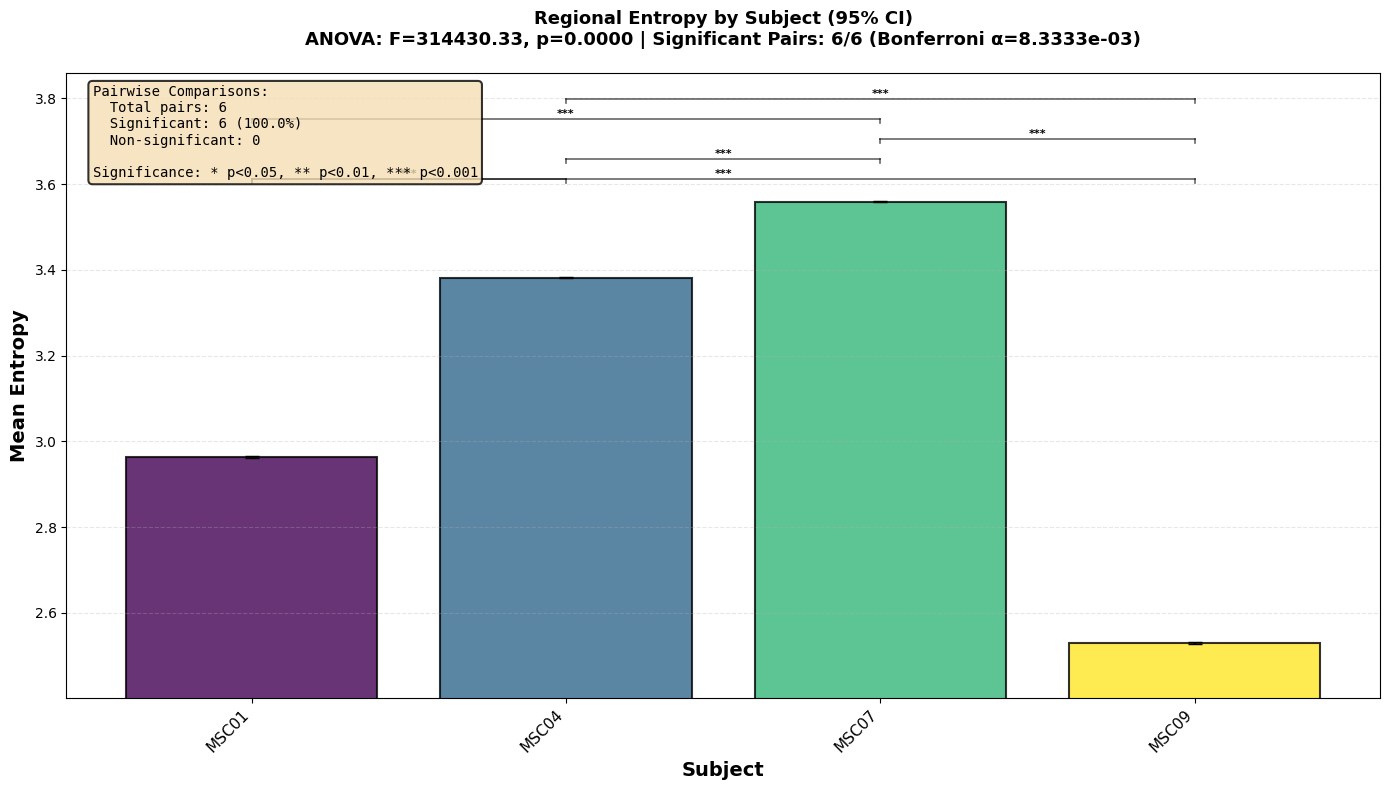

STATISTICAL SUMMARY
ANOVA: F=314430.3343, p=0.0000e+00

Pairwise Comparisons (Mann-Whitney U):
  Bonferroni-corrected α: 8.3333e-03
  Significant pairs: 6/6 (100.0%)

  *** ALL PAIRWISE COMPARISONS ARE SIGNIFICANT ***


In [18]:
# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
confidence_level = 0.95
degrees_freedom = n_regions - 1
sem_entropy = stats.sem(entropy_data, axis=1)
t_value = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
ci_entropy = t_value * sem_entropy

# Perform statistical tests
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# Post-hoc pairwise comparisons
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

# Calculate all pairwise comparisons
pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Count significant pairs
sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((i, j, pairwise_p[i, j]))

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Bar plot with 95% confidence intervals
x_pos = np.arange(n_subjects)
bars = ax.bar(x_pos, mean_entropy, yerr=ci_entropy, capsize=5, 
              alpha=0.8, color=plt.cm.viridis(np.linspace(0, 1, n_subjects)),
              edgecolor='black', linewidth=1.5)

ax.set_xlabel('Subject', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Entropy', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(subject_labels, rotation=45, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add title with statistics
title_text = f'Regional Entropy by Subject (95% CI)\n'
title_text += f'ANOVA: F={f_stat:.2f}, p={p_value_anova:.4f} | '
title_text += f'Significant Pairs: {len(sig_pairs)}/{n_comparisons} (Bonferroni α={bonferroni_alpha:.4e})'
ax.set_title(title_text, fontsize=13, fontweight='bold', pad=20)

# Draw significance brackets between all significant pairs
y_max = (mean_entropy + ci_entropy).max()
y_range = y_max - (mean_entropy - ci_entropy).min()
bracket_height = y_range * 0.03
starting_height = y_max + y_range * 0.05

# Sort pairs by distance to minimize overlap
sig_pairs_sorted = sorted(sig_pairs, key=lambda x: abs(x[0] - x[1]))

# Draw brackets in layers to reduce overlap
max_concurrent = 5  # Maximum number of brackets to show at same height
layer_heights = [starting_height + i * bracket_height * 1.5 for i in range(max_concurrent)]

for idx, (i, j, p) in enumerate(sig_pairs_sorted):
    layer = idx % max_concurrent
    y_height = layer_heights[layer]
    
    # Draw bracket
    x1, x2 = x_pos[i], x_pos[j]
    
    # Horizontal line
    ax.plot([x1, x2], [y_height, y_height], 'k-', linewidth=1.2, alpha=0.6)
    
    # Vertical ticks
    tick_height = bracket_height * 0.3
    ax.plot([x1, x1], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.6)
    ax.plot([x2, x2], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.6)
    
    # Add asterisk for significance level
    if p < 0.001:
        sig_marker = '***'
    elif p < 0.01:
        sig_marker = '**'
    elif p < 0.05:
        sig_marker = '*'
    else:
        sig_marker = ''
    
    # Only show asterisk on less crowded brackets
    # if layer < 2 or (j - i) <= 2:  # Show on close pairs or first two layers
    ax.text((x1 + x2) / 2, y_height + bracket_height * 0.01, sig_marker, 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Adjust y-axis to accommodate brackets
if len(sig_pairs) > 0:
    max_layer = min(len(sig_pairs) - 1, max_concurrent - 1)
    ax.set_ylim(bottom=(mean_entropy - ci_entropy).min() * 0.95, 
                top=layer_heights[max_layer] + bracket_height * 2)

# Add text box with summary statistics
summary_text = f'Pairwise Comparisons:\n'
summary_text += f'  Total pairs: {n_comparisons}\n'
summary_text += f'  Significant: {len(sig_pairs)} ({100*len(sig_pairs)/n_comparisons:.1f}%)\n'
summary_text += f'  Non-significant: {n_comparisons - len(sig_pairs)}\n'
summary_text += f'\nSignificance: * p<0.05, ** p<0.01, *** p<0.001'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')


plt.tight_layout()
plt.savefig('entropy_bar_plot_with_significance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(f"ANOVA: F={f_stat:.4f}, p={p_value_anova:.4e}")
print(f"\nPairwise Comparisons (Mann-Whitney U):")
print(f"  Bonferroni-corrected α: {bonferroni_alpha:.4e}")
print(f"  Significant pairs: {len(sig_pairs)}/{n_comparisons} ({100*len(sig_pairs)/n_comparisons:.1f}%)")
if len(sig_pairs) == n_comparisons:
    print("\n  *** ALL PAIRWISE COMPARISONS ARE SIGNIFICANT ***")
print("="*60)

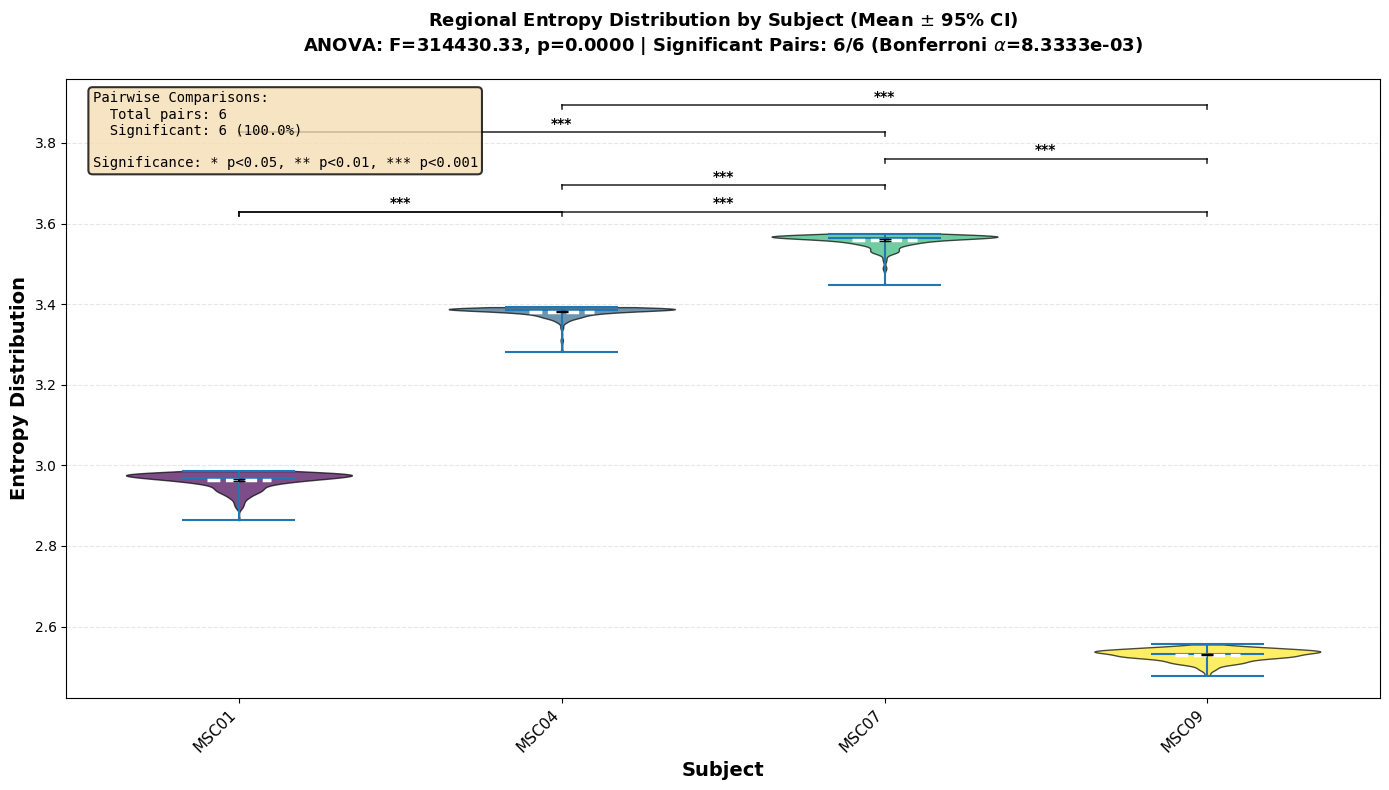

In [19]:

# --- STATISTICAL CALCULATIONS (From your original script) ---
# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
confidence_level = 0.95
n_regions = entropy_data.shape[1]
degrees_freedom = n_regions - 1
sem_entropy = stats.sem(entropy_data, axis=1)
t_value = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
ci_entropy = t_value * sem_entropy

# Perform statistical tests (ANOVA)
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# Post-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction)
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Count significant pairs
sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((i, j, pairwise_p[i, j]))


# --- VIOLIN PLOT CODE ---
fig, ax = plt.subplots(figsize=(14, 8))

# Data for violin plot (list of arrays)
data_to_plot = [entropy_data[i, :] for i in range(n_subjects)]
x_pos = np.arange(n_subjects)

# 1. Create the violin plots
violins = ax.violinplot(
    data_to_plot,
    positions=x_pos,
    vert=True,
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

# Color the violins
colors = plt.cm.viridis(np.linspace(0, 1, n_subjects))
for i, pc in enumerate(violins['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 2. Highlight mean and 95% CI with error bars
for i in range(n_subjects):
    # Mean as a dashed white line
    ax.hlines(mean_entropy[i], x_pos[i] - 0.1, x_pos[i] + 0.1, 
              color='white', linestyle='--', linewidth=2.5, zorder=3)
    # CI as a black error bar/whisker (using fmt='none' for just the error bars)
    ax.errorbar(x_pos[i], mean_entropy[i], yerr=ci_entropy[i], fmt='none', 
                color='black', capsize=4, markersize=4, linewidth=1.5, zorder=4)

# --- AXIS LABELS AND TITLE ---
ax.set_xlabel('Subject', fontsize=14, fontweight='bold')
ax.set_ylabel('Entropy Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(subject_labels, rotation=45, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

title_text = f'Regional Entropy Distribution by Subject (Mean $\\pm$ 95% CI)\n'
title_text += f'ANOVA: F={f_stat:.2f}, p={p_value_anova:.4f} | '
title_text += f'Significant Pairs: {len(sig_pairs)}/{n_comparisons} (Bonferroni $\\alpha$={bonferroni_alpha:.4e})'
ax.set_title(title_text, fontsize=13, fontweight='bold', pad=20)

# 3. Significance Brackets (adapted for the violin plot y-range)
y_max = entropy_data.max()
y_min = entropy_data.min()
y_range = y_max - y_min
bracket_height = y_range * 0.03
starting_height = y_max + y_range * 0.05

sig_pairs_sorted = sorted(sig_pairs, key=lambda x: abs(x[0] - x[1]))
max_concurrent = 5
layer_heights = [starting_height + i * bracket_height * 2 for i in range(max_concurrent)]

for idx, (i, j, p) in enumerate(sig_pairs_sorted):
    layer = idx % max_concurrent
    y_height = layer_heights[layer]
    x1, x2 = x_pos[i], x_pos[j]

    # Draw bracket
    ax.plot([x1, x2], [y_height, y_height], 'k-', linewidth=1.2, alpha=0.8)
    tick_height = bracket_height * 0.3
    ax.plot([x1, x1], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.8)
    ax.plot([x2, x2], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.8)

    # Add asterisk
    if p < 0.001:
        sig_marker = '***'
    elif p < 0.01:
        sig_marker = '**'
    elif p < 0.05:
        sig_marker = '*'
    else:
        sig_marker = ''

    ax.text((x1 + x2) / 2, y_height + bracket_height * 0.1, sig_marker,
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust y-axis to accommodate brackets
if len(sig_pairs) > 0:
    max_layer = min(len(sig_pairs) - 1, max_concurrent - 1)
    ax.set_ylim(bottom=y_min - y_range * 0.05,
                top=layer_heights[max_layer] + bracket_height * 2)

# Add text box with summary statistics
summary_text = f'Pairwise Comparisons:\n'
summary_text += f'  Total pairs: {n_comparisons}\n'
summary_text += f'  Significant: {len(sig_pairs)} ({100*len(sig_pairs)/n_comparisons:.1f}%)\n'
summary_text += f'\nSignificance: * p<0.05, ** p<0.01, *** p<0.001'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

## **Matrix Comparison**

In [25]:
subjects = [
            'MSC01', 
            # 'MSC02',
            # 'MSC03',
            'MSC04',
            # 'MSC05', 
            # 'MSC06',
            'MSC07', 
            # 'MSC08',
            'MSC09',
            # 'MSC10'
            ]

atlas = 'glasser360_SUIT_Thalamus'
atlas_subdir = 'glasser360_SUIT_Thalamus'

other_suffix = ''
cov = {}
cov[num_bins] = load_data(subjects=subjects, measure="covariance", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)

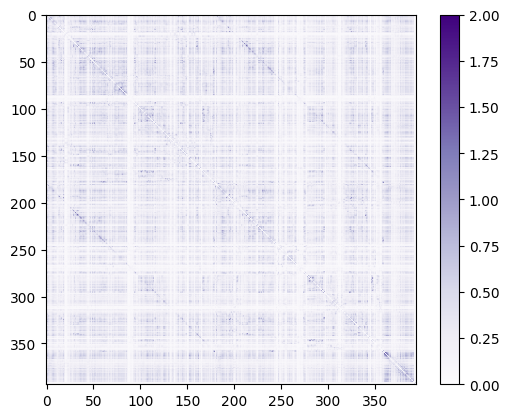

In [26]:
plt.imshow(mi_gst[100]['MSC09'], vmax=2, cmap='Purples')
plt.colorbar()

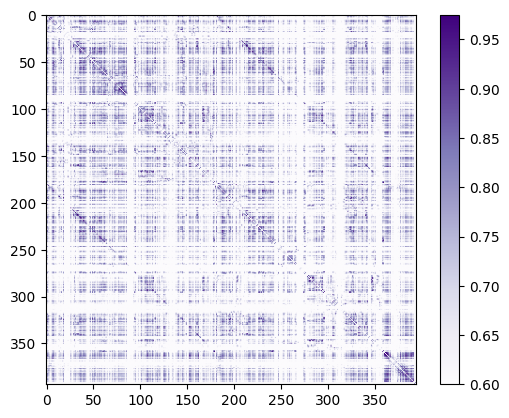

In [22]:
plt.imshow(cov[100]['MSC09'], vmin=0.6, vmax=max(cov[100]['MSC09'].flatten()), cmap='Purples')
plt.colorbar()

In [27]:
def select_networks_glasser360_SUIT_Thalamus(labels=list(glasser_region_list['cortex']) + ['Cerebellum']*32 + ['Thalamus']*2, networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Thalamus']):
    
    selected_nodes = []
    node_names = []
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return node_names, selected_nodes

In [28]:
node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])

In [29]:
# Get the indices that would sort sorting_key_array
sorted_indices = np.array(node_names).argsort()

# Use these indices to reorder array_to_sort
sorted_array_to_sort = np.array(selected_nodes)[sorted_indices]

print(sorted_array_to_sort)

[371 379 378 377 376 375 374 373 372 382 370 369 368 367 366 365 364 363
 362 361 360 383 384 385 386 387 388 389 390 391 380 381   7 232 231 230
 188 187  52  51  50   8 392 393]


In [30]:
print(np.array(node_names))

['Somatosensory_and_Motor' 'Somatosensory_and_Motor'
 'Somatosensory_and_Motor' 'Somatosensory_and_Motor'
 'Somatosensory_and_Motor' 'Somatosensory_and_Motor'
 'Somatosensory_and_Motor' 'Somatosensory_and_Motor'
 'Somatosensory_and_Motor' 'Somatosensory_and_Motor' 'Cerebellum'
 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum'
 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum'
 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum'
 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum'
 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum'
 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum' 'Cerebellum'
 'Cerebellum' 'Thalamus' 'Thalamus']


In [31]:
these_labels = np.array(all_labels)[selected_nodes]

In [32]:
these_labels

array(['4_R', '3b_R', '1_R', '2_R', '3a_R', '4_L', '3b_L', '1_L', '2_L',
       '3a_L', 'Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI',
       'Vermis_VI', 'Right_VI', 'Left_CrusI', 'Vermis_CrusI',
       'Right_CrusI', 'Left_CrusII', 'Vermis_CrusII', 'Right_CrusII',
       'Left_VIIb', 'Vermis_VIIb', 'Right_VIIb', 'Left_VIIIa',
       'Vermis_VIIIa', 'Right_VIIIa', 'Left_VIIIb', 'Vermis_VIIIb',
       'Right_VIIIb', 'Left_IX', 'Vermis_IX', 'Right_IX', 'Left_X',
       'Vermis_X', 'Right_X', 'Left_Dentate', 'Right_Dentate',
       'Left_Interposed', 'Right_Interposed', 'left_global',
       'right_global'], dtype='<U16')

In [33]:
selected_nodes = sorted_array_to_sort.tolist()

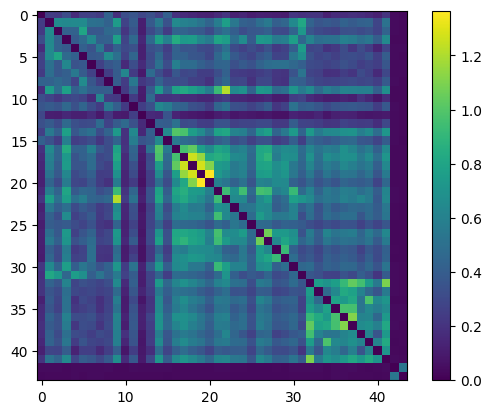

In [34]:
plt.imshow(mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)],  cmap='viridis')
plt.colorbar()

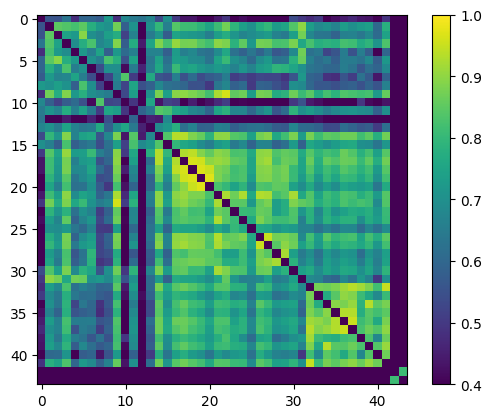

In [36]:
plt.imshow(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], vmin=0.4, vmax=1, cmap='viridis')
plt.colorbar()

In [39]:
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib import cm

def plot_mi_heatmap(mi_matrix, labels=None, figsize=(6,5), cmap='viridis', title='Pairwise MI Heatmap', vmin=0, vmax=None, order=None):
    # cluster ROIs to reveal blocks
    d = 1 - (mi_matrix / (mi_matrix.max() + 1e-12))  # rough dissimilarity
    # use only upper triangle to build linkage vector
    # flatten symmetric matrix into condensed distance matrix for linkage
    from scipy.spatial.distance import squareform
    dist = squareform(d, checks=False)
    Z = linkage(dist, method='average')
    if order is None:
        order = leaves_list(Z)
    ordered = mi_matrix[np.ix_(order, order)]
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(ordered, ax=ax, cmap=cmap, square=True, cbar_kws={'label':'MI (nats)'},
                xticklabels=[labels[i] for i in order] if labels is not None else False,
                yticklabels=[labels[i] for i in order] if labels is not None else False, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    plt.tight_layout()
    return fig, order


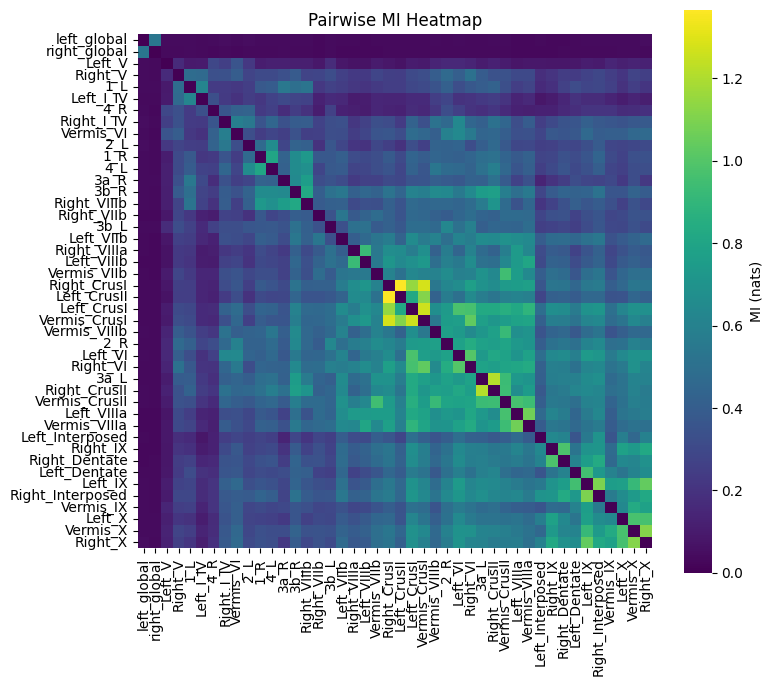

In [40]:
fig, order = plot_mi_heatmap(mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], labels=these_labels, figsize=(8,7))

(<Figure size 800x700 with 2 Axes>,
 array([42, 43, 12,  6,  4,  1, 31,  2,  5, 11, 15, 25, 28, 29, 23, 24, 19,
        20, 17, 18, 30,  9, 22, 21, 26, 27,  3, 14, 16, 40, 38, 33, 34, 39,
        32, 41, 35, 36, 37, 13,  7, 10,  0,  8], dtype=int32))

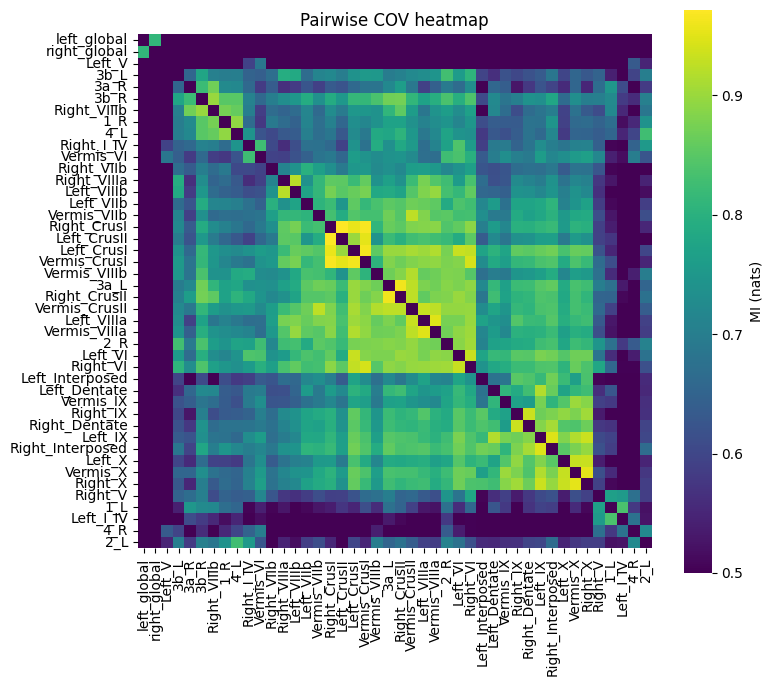

In [41]:
plot_mi_heatmap(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], labels=these_labels, figsize=(8,7), title='Pairwise COV heatmap', vmin=0.5)

In [268]:

from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from matplotlib import gridspec

def plot_mi_heatmap_clustered(mi_matrix, labels=None, system_labels=None,
                              n_clusters=10, cmap='viridis', figsize=(8,8), vmin=0, vmax=None, order=None, cbar_label = 'MI', title=''):
    """
    Enhanced clustered MI heatmap with clearer labels and cluster annotation.

    Args:
        mi_matrix : (n, n) symmetric MI matrix
        labels : list of ROI names
        system_labels : optional list of higher-level system labels (len=n)
                        e.g., ["Frontal", "Frontal", "Temporal", ...]
        n_clusters : number of clusters to mark on dendrogram
        cmap : colormap
    """
    # compute hierarchical clustering
    from scipy.spatial.distance import squareform
    d = 1 - (mi_matrix / (mi_matrix.max() + 1e-12))
    dist = squareform(d, checks=False)
    Z = linkage(dist, method='average')

    if order is None:
        order = leaves_list(Z)

    ordered = mi_matrix[np.ix_(order, order)]
    ordered_labels = [labels[i] for i in order] if labels is not None else order

    # prepare figure layout with dendrogram + heatmap
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 2, width_ratios=[0.2, 1], height_ratios=[0.2, 1])
    # ax_dendro_col = plt.subplot(gs[0,1])
    # ax_dendro_row = plt.subplot(gs[1,0])
    ax_heat = plt.subplot(gs[1,1])

    # # column dendrogram
    # dendro_col = dendrogram(Z, no_labels=True, color_threshold=None, above_threshold_color='gray',
    #                         ax=ax_dendro_col)
    # ax_dendro_col.axis('off')
    # # row dendrogram
    # dendro_row = dendrogram(Z, orientation='right', no_labels=True,
    #                         color_threshold=None, above_threshold_color='gray',
    #                         ax=ax_dendro_row)
    # ax_dendro_row.axis('off')

    # heatmap
    sns.heatmap(ordered, ax=ax_heat, cmap=cmap, square=True,
                # cbar=False,
                cbar_kws={'label': cbar_label},
                xticklabels=ordered_labels,
                yticklabels=ordered_labels, vmin=vmin, vmax=vmax)
    ax_heat.tick_params(axis='x', labelrotation=90, labelsize=7)
    ax_heat.tick_params(axis='y', labelsize=7)
    # ax_heat.set_title("Pairwise MI (clustered by ROI similarity)")

    # add cluster boundary lines
    from scipy.cluster.hierarchy import fcluster
    cluster_ids = fcluster(Z, t=n_clusters, criterion='maxclust')
    cluster_ordered = cluster_ids[order]
    # find boundaries between clusters
    boundaries = np.where(np.diff(cluster_ordered) != 0)[0]
    for b in boundaries:
        ax_heat.axhline(b+1, color='white', lw=1.5)
        ax_heat.axvline(b+1, color='white', lw=1.5)

    plt.tight_layout()


    # Optionally add cluster color bar or text labels (if system_labels given)
    if system_labels is not None:
        # map systems to colors
        unique_systems = list(dict.fromkeys(system_labels))  # preserve order
        palette = sns.color_palette("tab10", len(unique_systems))
        system_to_color = {s: palette[i] for i, s in enumerate(unique_systems)}
        colors = [system_to_color[system_labels[i]] for i in order]
        # add colored bar on top of heatmap
        for i, c in enumerate(colors):
            ax_heat.add_patch(plt.Rectangle((i, -2), 1, 1, fc=c, ec='none', transform=ax_heat.transData, clip_on=False))
        ax_heat.set_ylim(ax_heat.get_ylim())  # reset limits
        


    return fig, order


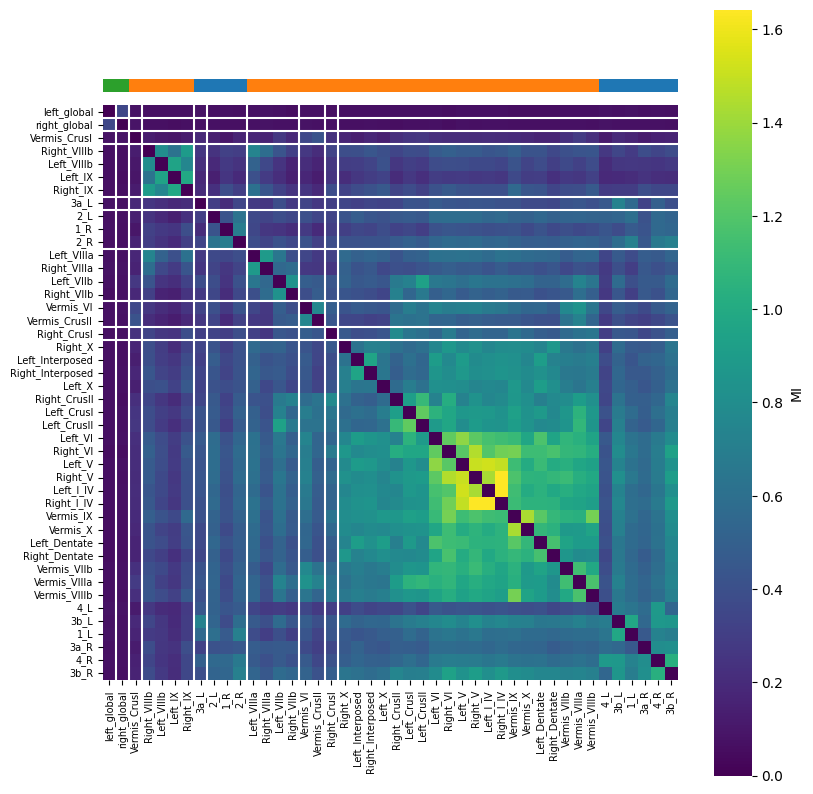

In [269]:
fig, order = plot_mi_heatmap_clustered(mi_gst[100]['MSC01'][np.ix_(selected_nodes, selected_nodes)], labels=these_labels, system_labels = node_names, figsize=(10,10), n_clusters=10, cbar_label='MI', title='MSC01 Pairwise MI Heatmap')

(<Figure size 1000x1000 with 2 Axes>,
 array([42, 43, 18, 31, 29, 32, 34,  9,  8,  2,  3, 26, 28, 23, 25, 15, 21,
        19, 37, 40, 41, 35, 22, 17, 20, 14, 16, 12, 13, 10, 11, 33, 36, 38,
        39, 24, 27, 30,  5,  6,  7,  4,  0,  1], dtype=int32))

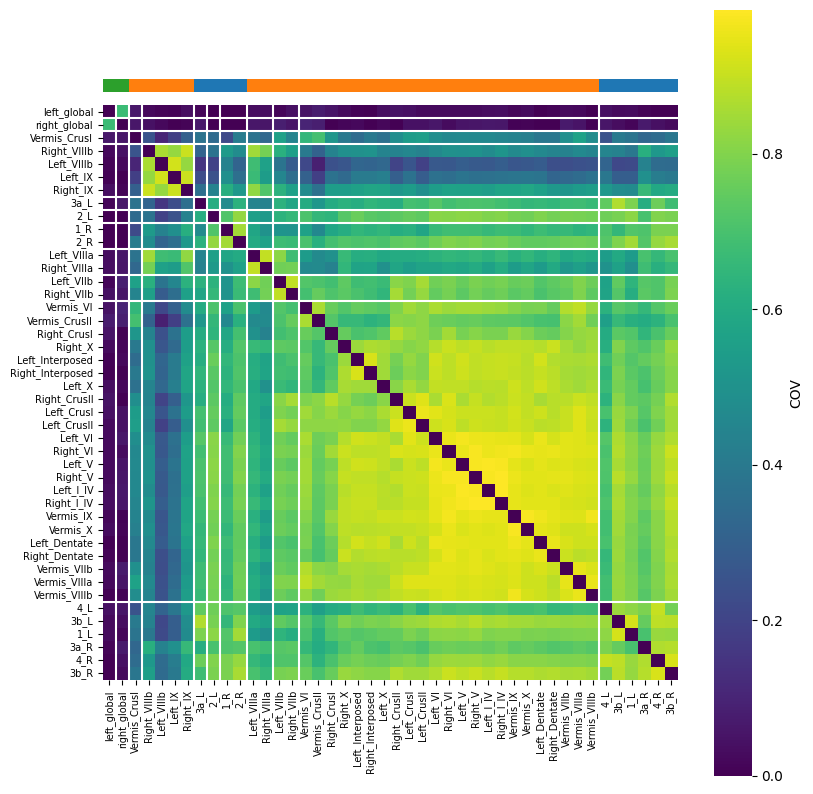

In [272]:
plot_mi_heatmap_clustered(cov[100]['MSC01'][np.ix_(selected_nodes, selected_nodes)], labels=these_labels, system_labels = node_names, figsize=(10,10), vmin=0, order=order, cbar_label='COV', title='MSC01 Pairwise COV Heatmap')

(<Figure size 1000x1000 with 3 Axes>,
 array([42, 43, 18, 17, 20, 23, 21, 15, 19, 22, 25, 28, 26, 29, 31, 37, 24,
        35, 40, 41, 36, 10, 11, 12, 13, 30, 27, 14, 16, 32, 34, 33, 38, 39,
         2,  3,  8,  4,  0,  1,  9,  7,  5,  6], dtype=int32))

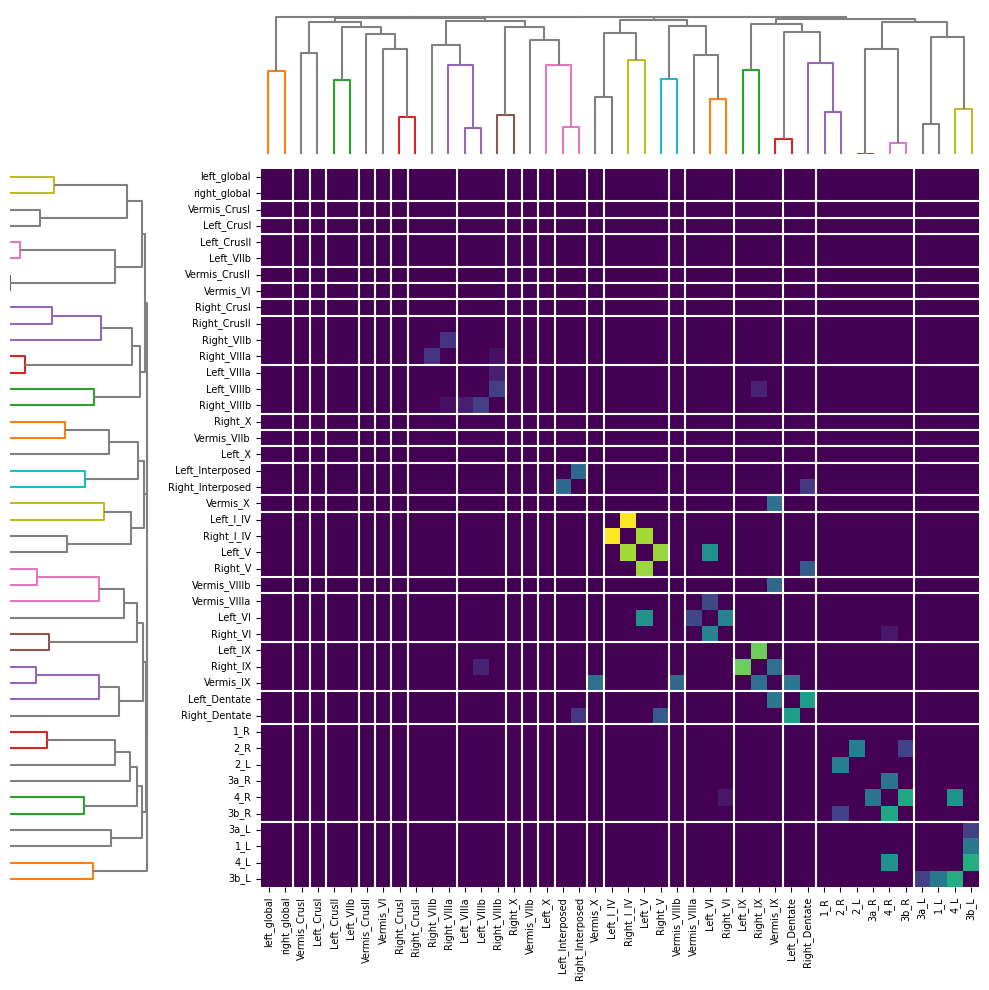

In [165]:
plot_mi_heatmap_clustered(nx.to_numpy_array(selective_cl_trees['MSC09']), labels=these_labels, system_labels = node_names, figsize=(10,10), vmin=0.7, order=order, cbar_label='CL', title='MSC01 Pairwise COV Heatmap')

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster

def plot_clustered_mi_with_labels(mi_matrix, labels=None, region_labels=None, figsize=(10,10)):
    """
    Plot clustered MI matrix with colored bars and text labels (Thalamus, Premotor, Motor, Cerebellum)
    Args:
        mi_matrix: (n, n) symmetric MI matrix
        labels: list of ROI names (len=n)
        region_labels: list of region categories (len=n), e.g. ['Thalamus', 'Premotor', ...]
    """

    # --- Clustering (optional ordering) ---
    d = 1 - (mi_matrix / (mi_matrix.max() + 1e-12))
    Z = linkage(d[np.triu_indices_from(d, 1)], method='average')
    order = leaves_list(Z)
    ordered = mi_matrix[np.ix_(order, order)]
    ordered_labels = [labels[i] for i in order] if labels is not None else order
    ordered_regions = [region_labels[i] for i in order] if region_labels is not None else None

    # --- Color mapping ---
    region_to_color = {
        'Thalamus': 'red',
        'Premotor': 'orange',
        'Motor': 'green',
        'Cerebellum': 'blue'
    }
    bar_colors = [region_to_color.get(r, 'gray') for r in ordered_regions]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(ordered, cmap='viridis', ax=ax, square=True,
                xticklabels=ordered_labels, yticklabels=ordered_labels,
                cbar_kws={'label': 'MI (nats)'})
    ax.tick_params(axis='x', labelrotation=90, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_title("Pairwise MI (clustered by ROI similarity)")

    # --- Add top color bar ---
    for i, color in enumerate(bar_colors):
        ax.add_patch(plt.Rectangle((i, -2), 1, 1, fc=color, ec='none', transform=ax.transData, clip_on=False))

    # --- Add text labels above clusters ---
    if ordered_regions is not None:
        unique_regions = []
        start_idx = 0
        for i in range(1, len(ordered_regions)):
            if ordered_regions[i] != ordered_regions[i-1]:
                unique_regions.append((ordered_regions[i-1], start_idx, i))
                start_idx = i
        unique_regions.append((ordered_regions[-1], start_idx, len(ordered_regions)))

        for region, start, end in unique_regions:
            mid = (start + end) / 2
            ax.text(mid, -4.5, region, color=region_to_color.get(region, 'gray'),
                    ha='center', va='bottom', fontsize=12, fontweight='bold', transform=ax.transData)

    plt.tight_layout()
    return fig


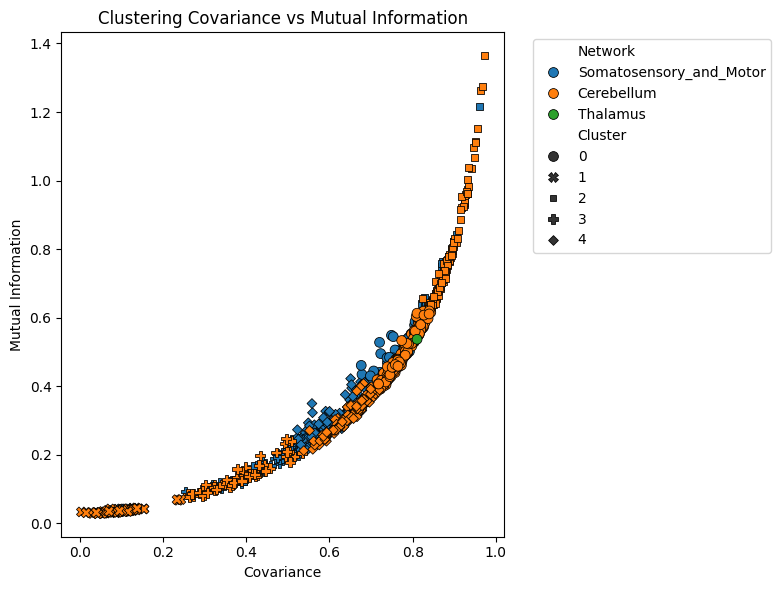

,Covariance,MutualInformation,Network,Pair,Cluster
0,0.558593,0.244263,Somatosensory_and_Motor,4_R-3b_R,4
1,0.553202,0.232162,Somatosensory_and_Motor,4_R-1_R,4
2,0.634298,0.318635,Somatosensory_and_Motor,4_R-2_R,4
3,0.479347,0.174269,Somatosensory_and_Motor,4_R-3a_R,3
4,0.595843,0.259522,Somatosensory_and_Motor,4_R-4_L,4
...,...,...,...,...,...
941,0.097573,0.036307,Cerebellum,Left_Interposed-left_global,1
942,0.091047,0.031755,Cerebellum,Left_Interposed-right_global,1
943,0.101039,0.037439,Cerebellum,Right_Interposed-left_global,1
944,0.095089,0.035779,Cerebellum,Right_Interposed-right_global,1


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

def compare_cov_mi_clustering(cov_matrix, mi_matrix, region_names, network_names, n_clusters=5):
    # cov_matrix, mi_matrix: (N_regions, N_regions) symmetric matrices
    # region_names, network_names: lists of str, len N_regions
    idxs = np.triu_indices_from(cov_matrix, k=1)
    cov_vals = cov_matrix[idxs]
    mi_vals = mi_matrix[idxs]
    pairs = [(region_names[i], region_names[j]) for i, j in zip(idxs[0], idxs[1])]
    networks = [network_names[i] for i, j in zip(idxs[0], idxs[1])]
    
    df = pd.DataFrame({
        'Covariance': cov_vals,
        'MutualInformation': mi_vals,
        'Network': networks,
        'Pair': [f'{ri}-{rj}' for ri, rj in pairs]
    })

    # KMeans clustering
    X = df[['Covariance', 'MutualInformation']].values
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)
    df['Cluster'] = kmeans.labels_

    # Plot
    plt.figure(figsize=(8, 6))
    scatter = sns.scatterplot(
        data=df, x='Covariance', y='MutualInformation',
        hue='Network', style='Cluster', palette='tab10', s=50, edgecolor='black')
    plt.title('Clustering Covariance vs Mutual Information')
    plt.xlabel('Covariance')
    plt.ylabel('Mutual Information')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return df


compare_cov_mi_clustering(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, n_clusters=5)


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

def side_by_side_cov_mi_clustering(cov_matrix, mi_matrix, region_names, network_names, n_clusters=5):
    # Extract upper triangle off-diagonal
    idxs = np.triu_indices_from(cov_matrix, k=1)
    cov_vals = cov_matrix[idxs]
    mi_vals = mi_matrix[idxs]
    region_pairs = [f'{region_names[i]}-{region_names[j]}' for i, j in zip(idxs[0], idxs[1])]
    networks = [network_names[i] for i, j in zip(idxs[0], idxs[1])]

    df = pd.DataFrame({
        'Covariance': cov_vals,
        'MutualInformation': mi_vals,
        'Network': networks,
        'Pair': region_pairs
    })

    # Clustering based on Covariance only
    kmeans_cov = KMeans(n_clusters=n_clusters, random_state=42).fit(df[['Covariance']])
    df['CovarianceCluster'] = kmeans_cov.labels_

    # Clustering based on MI only
    kmeans_mi = KMeans(n_clusters=n_clusters, random_state=42).fit(df[['MutualInformation']])
    df['MICluster'] = kmeans_mi.labels_

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
    sns.scatterplot(
        data=df, x='Covariance', y='MutualInformation',
        hue='Network', style='CovarianceCluster', palette='tab10', s=50, edgecolor='black', ax=axes[0])
    axes[0].set_title('Clusters by Covariance')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    sns.scatterplot(
        data=df, x='Covariance', y='MutualInformation',
        hue='Network', style='MICluster', palette='tab10', s=50, edgecolor='black', ax=axes[1])
    axes[1].set_title('Clusters by Mutual Information')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    return df

# Usage (supposing you have cov_matrix, mi_matrix, region_names, network_names):
# side_by_side_cov_mi_clustering(cov_matrix, mi_matrix, region_names, network_names, n_clusters=5)


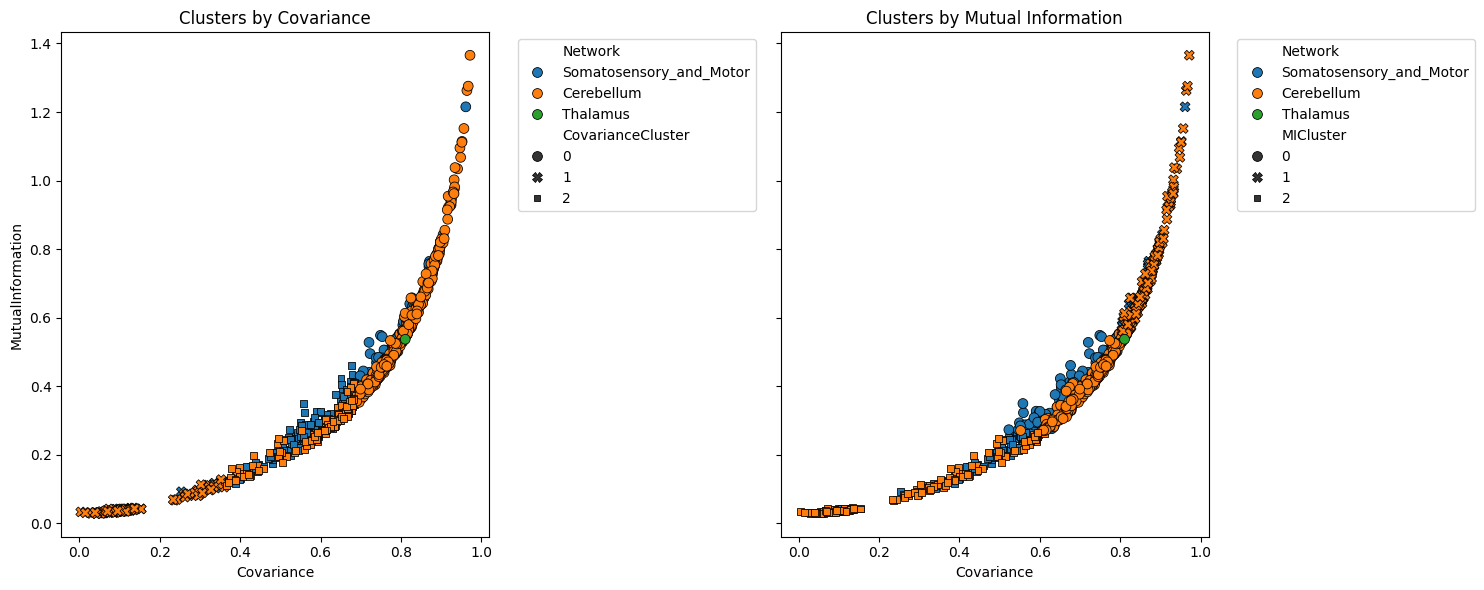

,Covariance,MutualInformation,Network,Pair,CovarianceCluster,MICluster
0,0.558593,0.244263,Somatosensory_and_Motor,4_R-3b_R,2,2
1,0.553202,0.232162,Somatosensory_and_Motor,4_R-1_R,2,2
2,0.634298,0.318635,Somatosensory_and_Motor,4_R-2_R,2,0
3,0.479347,0.174269,Somatosensory_and_Motor,4_R-3a_R,2,2
4,0.595843,0.259522,Somatosensory_and_Motor,4_R-4_L,2,2
...,...,...,...,...,...,...
941,0.097573,0.036307,Cerebellum,Left_Interposed-left_global,1,2
942,0.091047,0.031755,Cerebellum,Left_Interposed-right_global,1,2
943,0.101039,0.037439,Cerebellum,Right_Interposed-left_global,1,2
944,0.095089,0.035779,Cerebellum,Right_Interposed-right_global,1,2


In [82]:
side_by_side_cov_mi_clustering(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, n_clusters=3)

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

def standard_kmeans_visualization(cov_matrix, mi_matrix, region_names, network_names, n_clusters=5):
    # Prepare data
    idxs = np.triu_indices_from(cov_matrix, k=1)
    cov_vals = cov_matrix[idxs]
    mi_vals = mi_matrix[idxs]
    region_pairs = [f'{region_names[i]}-{region_names[j]}' for i, j in zip(idxs[0], idxs[1])]
    networks = [network_names[i] for i, j in zip(idxs[0], idxs[1])]
    
    df = pd.DataFrame({
        'Covariance': cov_vals,
        'MutualInformation': mi_vals,
        'Network': networks,
        'Pair': region_pairs
    })

    X = df[['Covariance', 'MutualInformation']].values
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_

    # Scatter plot with centroids
    plt.figure(figsize=(8, 6))
    scatter = sns.scatterplot(
        x=df['Covariance'], y=df['MutualInformation'],
        hue=df['Network'], style=df['Cluster'], palette='tab10',
        s=50, edgecolor='black', legend='brief'
    )
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
    plt.title('Standard KMeans Clustering')
    plt.xlabel('Covariance')
    plt.ylabel('Mutual Information')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return df, centroids

# Usage:
# standard_kmeans_visualization(cov_matrix, mi_matrix, region_names, network_names, n_clusters=5)


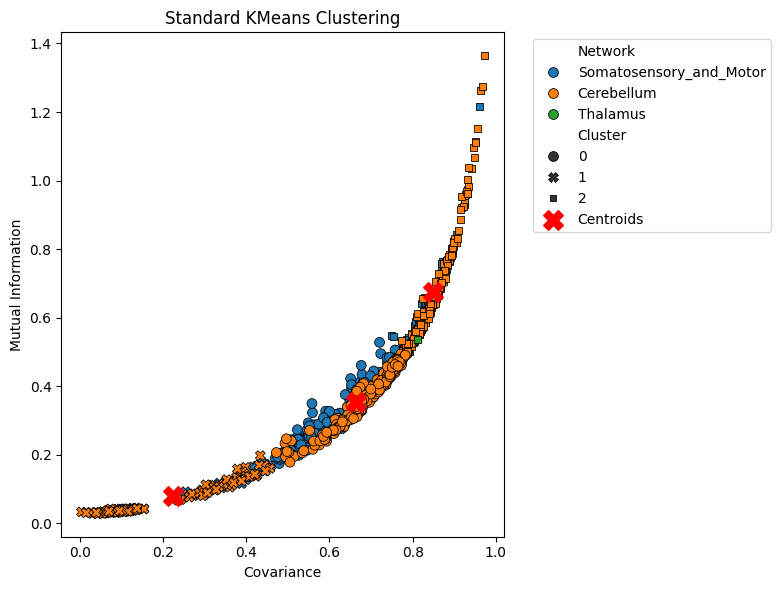

(     Covariance  MutualInformation                  Network  \
 0      0.558593           0.244263  Somatosensory_and_Motor   
 1      0.553202           0.232162  Somatosensory_and_Motor   
 2      0.634298           0.318635  Somatosensory_and_Motor   
 3      0.479347           0.174269  Somatosensory_and_Motor   
 4      0.595843           0.259522  Somatosensory_and_Motor   
 ..          ...                ...                      ...   
 941    0.097573           0.036307               Cerebellum   
 942    0.091047           0.031755               Cerebellum   
 943    0.101039           0.037439               Cerebellum   
 944    0.095089           0.035779               Cerebellum   
 945    0.810642           0.536836                 Thalamus   
 
                               Pair  Cluster  
 0                         4_R-3b_R        0  
 1                          4_R-1_R        0  
 2                          4_R-2_R        0  
 3                         4_R-3a_R       

In [84]:
standard_kmeans_visualization(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, n_clusters=3)

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Optional: Install UMAP with 'pip install umap-learn'
import umap

def cluster_visualization_umap_pca(cov_matrix, mi_matrix, region_names, network_names, n_clusters=5):
    # Prepare features
    idxs = np.triu_indices_from(cov_matrix, k=1)
    cov_vals = cov_matrix[idxs]
    mi_vals = mi_matrix[idxs]
    region_pairs = [f'{region_names[i]}-{region_names[j]}' for i, j in zip(idxs[0], idxs[1])]
    networks = [network_names[i] for i, j in zip(idxs[0], idxs[1])]

    df = pd.DataFrame({
        'Covariance': cov_vals,
        'MutualInformation': mi_vals,
        'Network': networks,
        'Pair': region_pairs
    })
    features = df[['Covariance', 'MutualInformation']].values

    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(features)

    # PCA projection
    pca = PCA(n_components=2)
    pc_proj = pca.fit_transform(features)
    df['PC1'] = pc_proj[:, 0]
    df['PC2'] = pc_proj[:, 1]

    # UMAP projection
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_proj = reducer.fit_transform(features)
    df['UMAP1'] = umap_proj[:, 0]
    df['UMAP2'] = umap_proj[:, 1]

    # Plot PCA
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=df['PC1'], y=df['PC2'],
                    hue=df['Network'], style=df['Cluster'],
                    palette='tab10', s=50, edgecolor='black')
    plt.title('PCA Projection of Clusters')

    # Plot UMAP
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=df['UMAP1'], y=df['UMAP2'],
                    hue=df['Network'], style=df['Cluster'],
                    palette='tab10', s=50, edgecolor='black')
    plt.title('UMAP Projection of Clusters')

    plt.tight_layout()
    plt.show()
    return df

# Usage:
# cluster_visualization_umap_pca(cov_matrix, mi_matrix, region_names, network_names, n_clusters=5)


/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


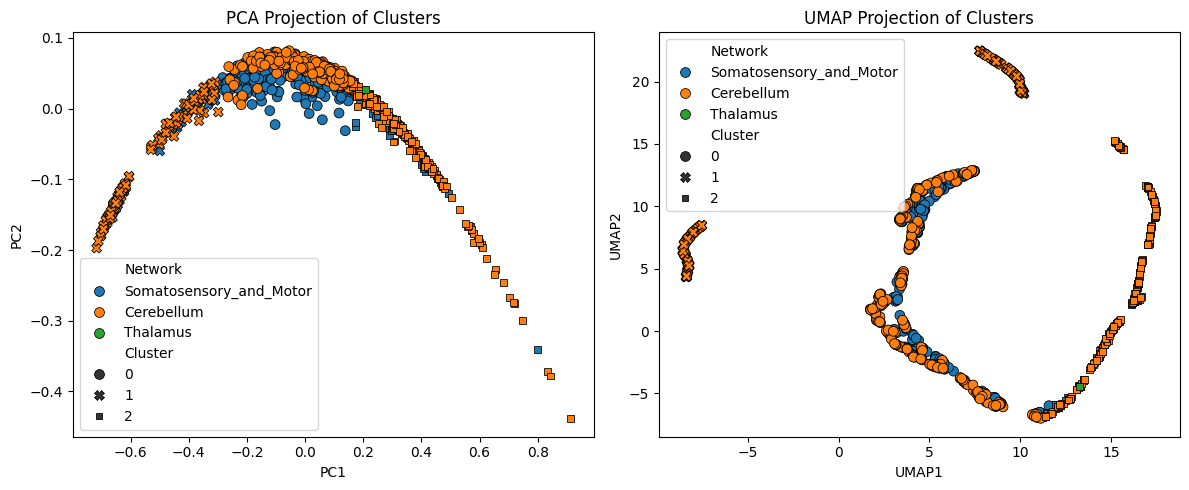

,Covariance,MutualInformation,Network,Pair,Cluster,PC1,PC2,UMAP1,UMAP2
0,0.558593,0.244263,Somatosensory_and_Motor,4_R-3b_R,0,-0.177492,0.051447,5.491928,11.733559
1,0.553202,0.232162,Somatosensory_and_Motor,4_R-1_R,0,-0.189909,0.056063,5.586542,12.126603
2,0.634298,0.318635,Somatosensory_and_Motor,4_R-2_R,0,-0.071386,0.053494,4.357512,7.881693
3,0.479347,0.174269,Somatosensory_and_Motor,4_R-3a_R,0,-0.282947,0.043807,7.477223,12.838686
4,0.595843,0.259522,Somatosensory_and_Motor,4_R-4_L,0,-0.140526,0.067383,4.244372,10.866292
...,...,...,...,...,...,...,...,...,...
941,0.097573,0.036307,Cerebellum,Left_Interposed-left_global,1,-0.648642,-0.132408,-8.492701,7.056652
942,0.091047,0.031755,Cerebellum,Left_Interposed-right_global,1,-0.656460,-0.133886,-8.584036,6.416319
943,0.101039,0.037439,Cerebellum,Right_Interposed-left_global,1,-0.645408,-0.130724,-8.333125,7.376027
944,0.095089,0.035779,Cerebellum,Right_Interposed-right_global,1,-0.650757,-0.133813,-8.532903,6.925978


In [89]:
cluster_visualization_umap_pca(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, n_clusters=3)

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

def cluster_and_visualize_single_matrix(matrix, region_names, network_names, method='pca', n_clusters=5):
    # Method: 'pca' or 'umap'
    idxs = np.triu_indices_from(matrix, k=1)
    vals = matrix[idxs]
    region_pairs = [f'{region_names[i]}-{region_names[j]}' for i, j in zip(idxs[0], idxs[1])]
    networks = [network_names[i] for i, j in zip(idxs[0], idxs[1])]

    df = pd.DataFrame({
        'Feature': vals,
        'Network': networks,
        'Pair': region_pairs
    })

    X = df[['Feature']].values  # Only one-dimensional
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(X)

    # Dimensionality reduction to 2D (single feature -> duplicated to make 2D for compatibility)
    if method == 'pca':
        pca = PCA(n_components=2)
        # Single-feature, so stack with zeros
        Xpca = np.hstack([X, np.zeros_like(X)])
        proj = pca.fit_transform(Xpca)
        xlabel, ylabel = 'PC1', 'PC2'
    elif method == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42)
        # Single-feature, so stack with zeros
        Xumap = np.hstack([X, np.zeros_like(X)])
        proj = reducer.fit_transform(Xumap)
        xlabel, ylabel = 'UMAP1', 'UMAP2'
    else:
        raise ValueError("method must be 'pca' or 'umap'")

    df[xlabel] = proj[:, 0]
    df[ylabel] = proj[:, 1]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=df[xlabel], y=df[ylabel],
        hue=df['Network'], style=df['Cluster'],
        palette='tab10', s=50, edgecolor='black'
    )
    plt.title(f'KMeans clustering on {xlabel}-{ylabel} ({method.upper()})')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return df

# Usage:
# To visualize clustering using only the mutual information matrix, choose method 'pca' or 'umap':
# cluster_and_visualize_single_matrix(mi_matrix, region_names, network_names, method='umap', n_clusters=5)
# For covariance:
# cluster_and_visualize_single_matrix(cov_matrix, region_names, network_names, method='pca', n_clusters=5)


/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


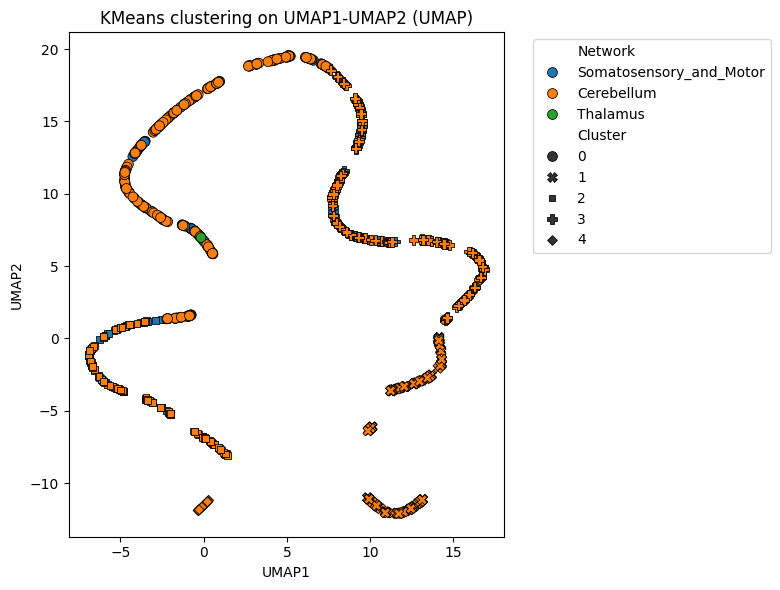

,Feature,Network,Pair,Cluster,UMAP1,UMAP2
0,1.095287,Somatosensory_and_Motor,4_R-3b_R,4,-0.260948,-11.845009
1,0.553227,Somatosensory_and_Motor,4_R-1_R,0,0.522792,5.871312
2,0.753516,Somatosensory_and_Motor,4_R-2_R,2,-0.521159,-6.461529
3,0.954298,Somatosensory_and_Motor,4_R-3a_R,4,0.047337,-11.503653
4,1.037803,Somatosensory_and_Motor,4_R-4_L,4,-0.175303,-11.750604
...,...,...,...,...,...,...
941,0.033411,Cerebellum,Left_Interposed-left_global,1,12.453215,-11.760315
942,0.031308,Cerebellum,Left_Interposed-right_global,1,12.951889,-11.336318
943,0.030928,Cerebellum,Right_Interposed-left_global,1,13.018713,-11.269342
944,0.028379,Cerebellum,Right_Interposed-right_global,1,13.132915,-11.156645


In [116]:
cluster_and_visualize_single_matrix(mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, method='umap', n_clusters=5)

/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


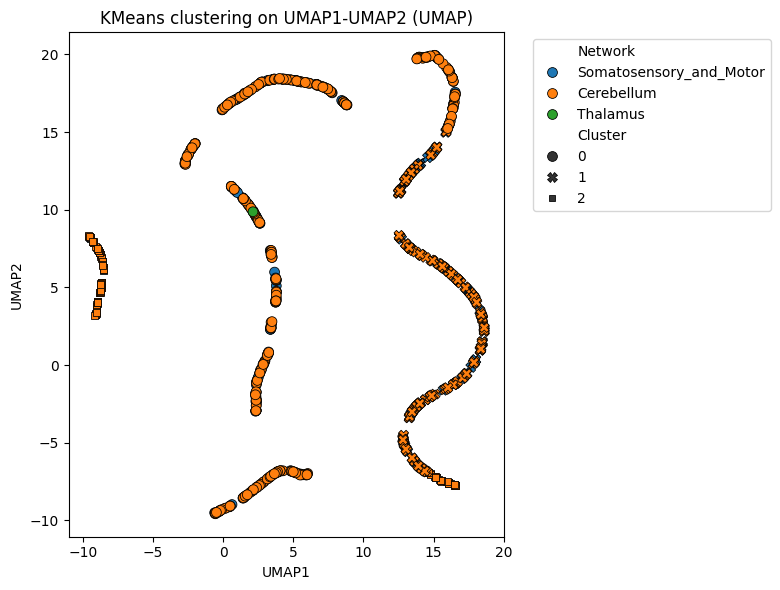

,Feature,Network,Pair,Cluster,UMAP1,UMAP2
0,0.946679,Somatosensory_and_Motor,4_R-3b_R,0,5.898700,-7.064317
1,0.816077,Somatosensory_and_Motor,4_R-1_R,0,2.603465,9.139565
2,0.883964,Somatosensory_and_Motor,4_R-2_R,0,2.403857,-7.863645
3,0.917380,Somatosensory_and_Motor,4_R-3a_R,0,4.885155,-6.842559
4,0.934503,Somatosensory_and_Motor,4_R-4_L,0,5.620970,-7.059478
...,...,...,...,...,...,...
941,0.061047,Cerebellum,Left_Interposed-left_global,2,-9.285621,7.936652
942,0.068555,Cerebellum,Left_Interposed-right_global,2,-8.998924,7.523476
943,0.039982,Cerebellum,Right_Interposed-left_global,2,-9.571169,8.265888
944,0.053618,Cerebellum,Right_Interposed-right_global,2,-9.308564,7.970966


In [115]:
cluster_and_visualize_single_matrix(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, method='umap', n_clusters=3)

In [ ]:
selective_cl_trees, selective_cl_joint_probs, selected_nodes = get_selective_chow_liu_trees(mi_gst[100], mi_joint_probs_gst[100], atlas_name='glasser360_SUIT_Thalamus_Brainstem',subjects=subjects, selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])

In [113]:
selective_cl_trees['MSC09']

/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


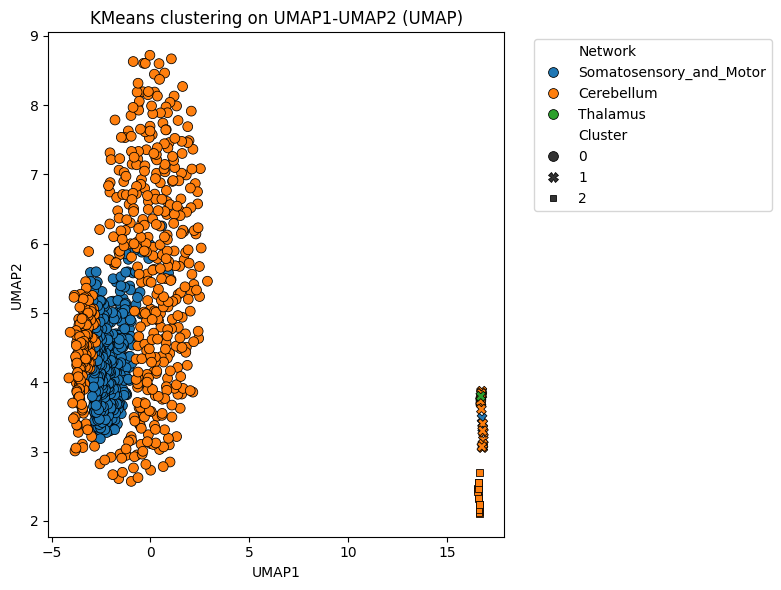

,Feature,Network,Pair,Cluster,UMAP1,UMAP2
0,1.095287,Somatosensory_and_Motor,4_R-3b_R,2,16.641052,2.216831
1,0.000000,Somatosensory_and_Motor,4_R-1_R,0,0.922277,5.575522
2,0.000000,Somatosensory_and_Motor,4_R-2_R,0,-0.007492,5.983193
3,0.954298,Somatosensory_and_Motor,4_R-3a_R,2,16.560402,2.467385
4,1.037803,Somatosensory_and_Motor,4_R-4_L,2,16.629713,2.258851
...,...,...,...,...,...,...
941,0.000000,Cerebellum,Left_Interposed-left_global,0,-1.422255,6.062900
942,0.000000,Cerebellum,Left_Interposed-right_global,0,-0.309682,5.894969
943,0.000000,Cerebellum,Right_Interposed-left_global,0,-1.731262,5.725579
944,0.000000,Cerebellum,Right_Interposed-right_global,0,-0.826247,5.998340


In [114]:
cluster_and_visualize_single_matrix(nx.to_numpy_array(selective_cl_trees['MSC09']), these_labels, node_names, method='umap', n_clusters=3)

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

def cluster_and_visualize_colored_by_cluster(matrix, region_names, network_names, method='pca', n_clusters=5):
    # matrix: (N_regions, N_regions)
    # region_names, network_names: lists of region and network labels
    idxs = np.triu_indices_from(matrix, k=1)
    vals = matrix[idxs]
    region_pairs = [f'{region_names[i]}-{region_names[j]}' for i, j in zip(idxs[0], idxs[1])]
    networks = [network_names[i] for i, j in zip(idxs[0], idxs[1])]

    df = pd.DataFrame({
        'Feature': vals,
        'Network': networks,
        'Pair': region_pairs
    })

    X = df[['Feature']].values
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(X)

    # Project to 2D for visualization (with dummy second column)
    if method == 'pca':
        pca = PCA(n_components=2)
        Xpca = np.hstack([X, np.zeros_like(X)])
        proj = pca.fit_transform(Xpca)
        xlabel, ylabel = 'PC1', 'PC2'
    elif method == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42)
        Xumap = np.hstack([X, np.zeros_like(X)])
        proj = reducer.fit_transform(Xumap)
        xlabel, ylabel = 'UMAP1', 'UMAP2'
    else:
        raise ValueError("method must be 'pca' or 'umap'")
    df[xlabel] = proj[:, 0]
    df[ylabel] = proj[:, 1]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=xlabel, y=ylabel,
        hue="Cluster", style="Network",
        data=df, palette="tab10", s=50, edgecolor="black"
    )
    plt.title(f'KMeans clusters (color) & network groups (shape) using {method.upper()}')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return df

# Usage:
# cluster_and_visualize_colored_by_cluster(mi_matrix, region_names, network_names, method='umap', n_clusters=5)
# cluster_and_visualize_colored_by_cluster(cov_matrix, region_names, network_names, method='pca', n_clusters=5)


/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


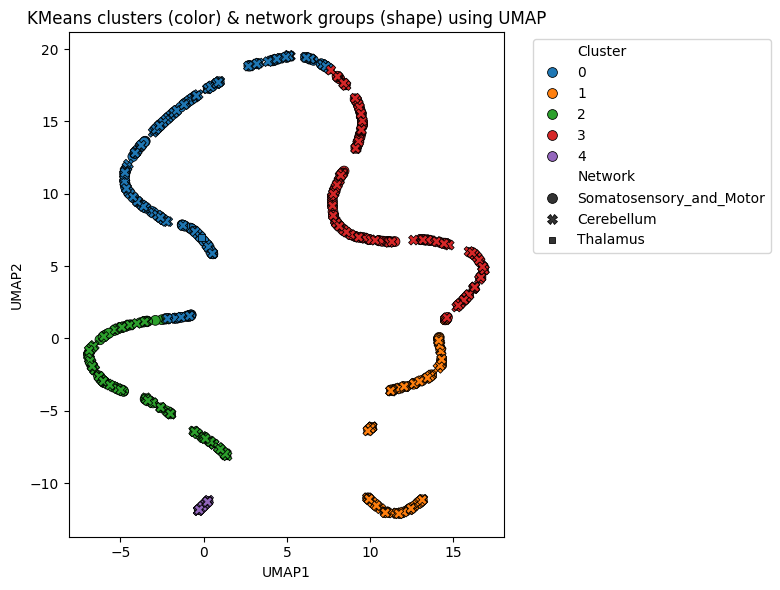

,Feature,Network,Pair,Cluster,UMAP1,UMAP2
0,1.095287,Somatosensory_and_Motor,4_R-3b_R,4,-0.260948,-11.845009
1,0.553227,Somatosensory_and_Motor,4_R-1_R,0,0.522792,5.871312
2,0.753516,Somatosensory_and_Motor,4_R-2_R,2,-0.521159,-6.461529
3,0.954298,Somatosensory_and_Motor,4_R-3a_R,4,0.047337,-11.503653
4,1.037803,Somatosensory_and_Motor,4_R-4_L,4,-0.175303,-11.750604
...,...,...,...,...,...,...
941,0.033411,Cerebellum,Left_Interposed-left_global,1,12.453215,-11.760315
942,0.031308,Cerebellum,Left_Interposed-right_global,1,12.951889,-11.336318
943,0.030928,Cerebellum,Right_Interposed-left_global,1,13.018713,-11.269342
944,0.028379,Cerebellum,Right_Interposed-right_global,1,13.132915,-11.156645


In [118]:
cluster_and_visualize_colored_by_cluster(mi_gst[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, method='umap', n_clusters=5)

/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


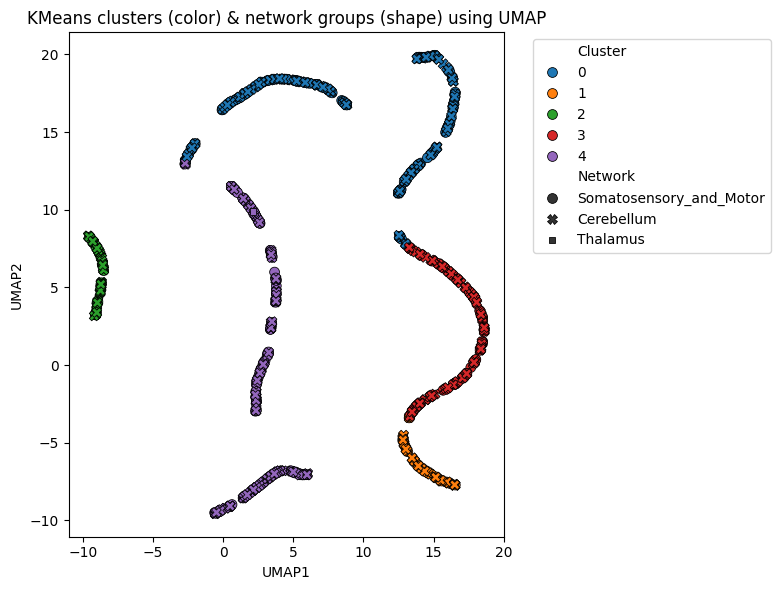

,Feature,Network,Pair,Cluster,UMAP1,UMAP2
0,0.946679,Somatosensory_and_Motor,4_R-3b_R,4,5.898700,-7.064317
1,0.816077,Somatosensory_and_Motor,4_R-1_R,4,2.603465,9.139565
2,0.883964,Somatosensory_and_Motor,4_R-2_R,4,2.403857,-7.863645
3,0.917380,Somatosensory_and_Motor,4_R-3a_R,4,4.885155,-6.842559
4,0.934503,Somatosensory_and_Motor,4_R-4_L,4,5.620970,-7.059478
...,...,...,...,...,...,...
941,0.061047,Cerebellum,Left_Interposed-left_global,2,-9.285621,7.936652
942,0.068555,Cerebellum,Left_Interposed-right_global,2,-8.998924,7.523476
943,0.039982,Cerebellum,Right_Interposed-left_global,2,-9.571169,8.265888
944,0.053618,Cerebellum,Right_Interposed-right_global,2,-9.308564,7.970966


In [119]:
cluster_and_visualize_colored_by_cluster(cov[100]['MSC09'][np.ix_(selected_nodes, selected_nodes)], these_labels, node_names, method='umap', n_clusters=5)

/opt/anaconda3/envs/dynamric/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


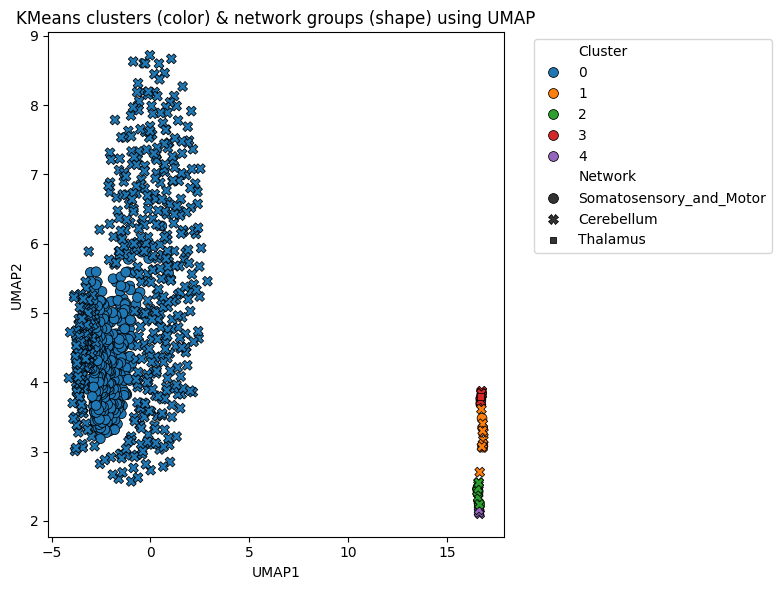

,Feature,Network,Pair,Cluster,UMAP1,UMAP2
0,1.095287,Somatosensory_and_Motor,4_R-3b_R,2,16.641052,2.216831
1,0.000000,Somatosensory_and_Motor,4_R-1_R,0,0.922277,5.575522
2,0.000000,Somatosensory_and_Motor,4_R-2_R,0,-0.007492,5.983193
3,0.954298,Somatosensory_and_Motor,4_R-3a_R,2,16.560402,2.467385
4,1.037803,Somatosensory_and_Motor,4_R-4_L,2,16.629713,2.258851
...,...,...,...,...,...,...
941,0.000000,Cerebellum,Left_Interposed-left_global,0,-1.422255,6.062900
942,0.000000,Cerebellum,Left_Interposed-right_global,0,-0.309682,5.894969
943,0.000000,Cerebellum,Right_Interposed-left_global,0,-1.731262,5.725579
944,0.000000,Cerebellum,Right_Interposed-right_global,0,-0.826247,5.998340


In [120]:
cluster_and_visualize_colored_by_cluster(nx.to_numpy_array(selective_cl_trees['MSC09']), these_labels, node_names, method='umap', n_clusters=5)

## **Chow-Liu trees**

In [95]:
subjects = [
            'MSC01', 
            # 'MSC02',
            # 'MSC03',
            'MSC04',
            # 'MSC05', 
            # 'MSC06',
            'MSC07', 
            # 'MSC08',
            'MSC09',
            # 'MSC10'
            ]

atlas = 'glasser360_SUIT_Thalamus'
atlas_subdir = 'glasser360_SUIT_Thalamus'

def load_data(subjects=subjects, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=100):
    """
    Save the covariance matrix to a CSV file.
    """
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        if skl:
            file_name = f'{task}_skl_{num_bins}bins'
        else:
            file_name = f'{task}_{num_bins}bins'

        data[subject] = torch.from_numpy(np.load(f'{data_path}/{file_name}.npy'))
    return data

def plot_connectome(cov_matrix, coords, title='connectome', edge_threshold="0%", edge_vmin=0, edge_vmax=1):
    """
    Plot the connectome using the mean correlation matrix and coordinates.
    """
    # Plotting the connectome
    plotting.plot_connectome(
        cov_matrix,
        coords,
        title=title,
        edge_vmin = edge_vmin,
        edge_vmax = edge_vmax,
        edge_cmap='cold_hot',
        edge_threshold=edge_threshold,  # Only plot edges above the 90th percentile
        colorbar=True,
        node_size=10,
    )
    plt.show()

def mi_to_graph(mi, selected_nodes=None):
    
    # Create a graph
    G = nx.Graph()
    num_variables = mi.shape[0]
    
    if selected_nodes is not None:
        for i in selected_nodes:
            G.add_node(i)
        
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(selected_nodes[i], selected_nodes[j], weight=mi[i, j])

    else:
        # Add nodes (variables)
        for i in range(num_variables):
            G.add_node(i)

    # Add edges with mutual information as weights
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(i, j, weight=mi[i, j])
    
    return G

def chow_liu_tree(mi):
    
    # Create a graph
    G = mi_to_graph(mi)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_chow_liu_trees(mi, joint_probs, subjects=subjects):

    cl_trees = {}
    cl_matrices = {}
    cl_joint_probs = {}
    for subject in subjects:
        _, cl_trees[subject] = chow_liu_tree(mi[subject])
        cl_matrices[subject] = torch.from_numpy(nx.to_numpy_array(cl_trees[subject], weight='weight'))
        cl_joint_probs[subject] = {}
        for edge in cl_trees[subject].edges():
            i, j = edge
            cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return cl_trees, cl_matrices, cl_joint_probs

def draw_chow_liu_tree(G, root=0):
    """
    Visualize the Chow-Liu tree using a spring layout (no pygraphviz).
    """
    tree = nx.bfs_tree(G, source=root)
    pos = nx.spring_layout(tree, seed=42)

    plt.figure(figsize=(8, 6))
    nx.draw(tree, pos, with_labels=True, arrows=False, node_color="lightblue", 
            edge_color="black", node_size=1500, font_size=12)
    
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels)

    plt.title("Chow-Liu Tree (Spring Layout)")
    plt.axis("off")
    plt.show()


def hierarchy_pos(G, root=None, width=1., vert_gap=0.5, vert_loc=0, xcenter=0.5):
    """
    Hierarchical layout for directed trees. Assigns space to subtrees to avoid squishing.
    """
    def _count_descendants(G, node):
        children = list(G.successors(node))
        if not children:
            return 1
        return sum(_count_descendants(G, child) for child in children)

    def _hierarchy_pos(G, node, left, right, vert_loc, pos, extra=0):
        center = (left + right) / 2
        pos[node] = (center, vert_loc)
        children = list(G.successors(node))
        if children:
            total = sum(_count_descendants(G, child) for child in children)
            dx = (right - left) / total
            next_left = left
            for child in children:
                size = _count_descendants(G, child)
                next_right = next_left + dx * size
                pos = _hierarchy_pos(G, child, next_left, next_right, vert_loc - vert_gap, pos)
                next_left = next_right
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, {})

def get_node_regions(tree, network_labels=None, region_labels=None, atlas_name='schaefer'):

    if atlas_name == 'schaefer':
        networks = []
        for node in tree.nodes:
            network = str(network_labels[node]).split('_')[2]
            networks.append(network)
        return networks
    
    elif atlas_name == 'glasser_suit':
        networks = []
        network_labels = list(region_labels) + ['Cerebellum']*32
        for node in tree.nodes:
            network = network_labels[node]
            networks.append(network)
        return networks
    
    elif atlas_name == 'glasser360_SUIT_Thalamus':
        networks = []
        network_labels = list(region_labels) + ['Cerebellum']*32 + ['Thalamus']*2
        for node in tree.nodes:
            network = network_labels[node]
            networks.append(network)
        return networks
    
def draw_hierarchical_tree(G, root=0, atlas_name='glasser_suit', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title = "Hierarchical Chow-Liu Tree", draw_tree=True, selected_networks=None, region_names=None, node_size=400, font_size=6, figsize=(10, 6), extra_position=0):
    """
    Draw Chow-Liu tree in a hierarchical top-down format.
    """
    # Ensure it's a directed tree rooted at `root`
    tree = nx.bfs_tree(G, source=root)

    if not draw_tree:
        tree = G

    pos = hierarchy_pos(tree, root)
    if atlas_name == 'schaefer':
        networks = get_node_regions(tree, atlas_name='schaefer', network_labels=schaefer.labels)
    
    elif atlas_name == 'glasser_suit':
        networks = get_node_regions(tree, atlas_name='glasser_suit', region_labels=glasser_region_list['cortex'])
    
    elif atlas_name == 'glasser360_SUIT_Thalamus':
        networks = get_node_regions(tree, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])

    if atlas_name == 'schaefer':
        # Create a color map based on the networks

        network_names = ['Cont', 'Default', 'DorsAttn', 'Limbic', 'SalVentAttn', 'SomMot', 'Vis']
        colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
        
        if num_schaefer_networks == 17:
            network_names = ['ContA',
                            'ContB',
                            'ContC',
                            'DefaultA',
                            'DefaultB',
                            'DefaultC',
                            'DorsAttnA',
                            'DorsAttnB',
                            'LimbicA',
                            'LimbicB',
                            'SalVentAttnA',
                            'SalVentAttnB',
                            'SomMotA',
                            'SomMotB',
                            'TempPar',
                            'VisCent',
                            'VisPeri']
            
            colors = colors = [
                                "#e6194b",  # red
                                "#3cb44b",  # green
                                "#ffe119",  # yellow
                                "#4363d8",  # blue
                                "#f58231",  # orange
                                "#911eb4",  # purple
                                "#46f0f0",  # cyan
                                "#f032e6",  # magenta
                                "#bcf60c",  # lime
                                "#fabebe",  # pink
                                "#008080",  # teal
                                "#e6beff",  # lavender
                                "#9a6324",  # brown
                                "#fffac8",  # beige
                                "#800000",  # maroon
                                "#aaffc3",  # mint
                                "#808000",  # olive      
                            ]
    
    if atlas_name == 'glasser_suit':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum']
        colors =          [
                            "#e6194b",  # red
                            "#3cb44b",  # green
                            "#ffe119",  # yellow
                            "#4363d8",  # blue
                            "#f58231",  # orange
                            "#911eb4",  # purple
                            "#46f0f0",  # cyan
                            "#f032e6",  # magenta
                            "#bcf60c",  # lime
                            "#fabebe",  # pink
                            "#008080",  # teal
                            "#e6beff",  # lavender
                            "#9a6324",  # brown
                            "#fffac8",  # beige
                            "#800000",  # maroon
                            "#aaffc3",  # mint
                            "#808000",  # olive
                            "#000075",  # navy
                            "#ffd8b1",  # peach
                            "#469990",  # turquoise
                            "#000000",  # black
                            "#ffffff",  # white
                            "#d2691e",  # chocolate
                            "#ff7f50",  # coral
                        ]
    if atlas_name == 'glasser360_SUIT_Thalamus':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']

        colors =          [
                            "#e6194b",  # red
                            "#3cb44b",  # green
                            "#ffe119",  # yellow
                            "#4363d8",  # blue
                            "#f58231",  # orange
                            "#911eb4",  # purple
                            "#46f0f0",  # cyan
                            "#f032e6",  # magenta
                            "#bcf60c",  # lime
                            "#fabebe",  # pink
                            "#008080",  # teal
                            "#e6beff",  # lavender
                            "#9a6324",  # brown
                            "#fffac8",  # beige
                            "#800000",  # maroon
                            "#aaffc3",  # mint
                            "#808000",  # olive
                            "#000075",  # navy
                            "#ffd8b1",  # peach
                            "#469990",  # turquoise
                            "#000000",  # black
                            "#ffffff",  # white
                            "#d2691e",  # chocolate
                            "#ff7f50",  # coral
                            "#40e0d0",  # turquoise bright
                            "#ff1493",  # deep pink
                            "#7fff00",  # chartreuse
                            "#1e90ff",  # dodger blue
                            "#ff4500",  # orange red
                            "#daa520",  # goldenrod
                        ]
        
        network_purples = [
            "#E1BEE7",  # Light (for background/less important)
            "#E0E0E0",  # Light Grey
            "#9FA8DA",  # Soft Violet
            "#7B1FA2",  # Dark
            "#4A148C",  # Very dark (for emphasis)
        ]
                
        if selected_networks is not None:
            network_names = selected_networks

            # edit later
            colors = network_purples[:len(selected_networks)]

    color_map = []
    print(networks)
    for node, network in zip(tree.nodes, networks):
        if network in network_names:
            color = colors[network_names.index(network)]
            color_map.append(color)
        else:
            color_map.append('white')
    # print(color_map)
    
    # color_map = np.array(color_map)
    # color_map = color_map / max(color_map)
    if region_names is not None and len(region_names) >= len(tree.nodes):
        node_labels = {node: region_names[node] for node in tree.nodes}
    else:
        # Fallback: just display numbers
        node_labels = {node: str(node) for node in tree.nodes}
    
    plt.figure(figsize=figsize)
    nx.draw(tree, pos, with_labels=True, labels=node_labels, node_color=color_map, node_size=node_size,
            arrows=False, font_size=font_size, edge_color='gray')


    # edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    # nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size = 0)

    patches = [mpatches.Patch(color=color, label=network_name) for color, network_name in zip(colors, network_names)]
    plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

    return tree, pos, network_names, colors

In [96]:
def select_networks_schaefer(schaefer, networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    selected_nodes = []
    for i, label in enumerate(schaefer.labels):
        network = str(label).split('_')[2]
        if network in networks:
            selected_nodes.append(i)
    return selected_nodes

def select_networks_glasser(labels=list(glasser_region_list['cortex'])+['Cerebellum']*32, networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum']):
    
    selected_nodes = []
    node_names = []
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return selected_nodes

def select_networks_glasser360_SUIT_Thalamus(labels=list(glasser_region_list['cortex']) + ['Cerebellum']*32 + ['Thalamus']*2, networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Thalamus']):
    
    selected_nodes = []
    node_names = []
    print(labels)
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return node_names, selected_nodes

def selective_chow_liu_tree(mi, selected_nodes):
    
    # Create a graph
    selected_mi = mi[np.ix_(selected_nodes, selected_nodes)]
    
    G = mi_to_graph(selected_mi, selected_nodes=selected_nodes)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_selective_chow_liu_trees(mi, joint_probs, subjects=subjects, atlas_name='glasser_suit', schaefer=None, selected_networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    if atlas_name == 'schaefer':
        node_names, selected_nodes = select_networks_schaefer(schaefer, networks=selected_networks)
    
    if atlas_name == 'glasser_suit':
        node_names, selected_nodes = select_networks_glasser(networks=selected_networks)
    
    if atlas_name == 'glasser360_SUIT_Thalamus_Brainstem':
        node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks)

    print(node_names)
    print(selected_nodes)
    selective_cl_trees = {}
    selective_cl_joint_probs = {}
    
    for subject in subjects:
        _, selective_cl_trees[subject] = selective_chow_liu_tree(mi[subject], selected_nodes=selected_nodes)
        selective_cl_joint_probs[subject] = {}
        for edge in selective_cl_trees[subject].edges():
            i, j = edge
            selective_cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return selective_cl_trees, selective_cl_joint_probs, selected_nodes

In [97]:
# def sparse_covariance_top_edges(cov_matrix, atlas_name = 'glasser360_SUIT_Thalamus_Brainstem', selected_networks=None, selected_nodes=None):
#     """
#     Get the top N edges with the highest covariance values.
#     """

#     top_n=cov_matrix.shape[0]  # Number of nodes
#     # Flatten the covariance matrix and get the indices of the top N values
#     flat_indices = np.argsort(cov_matrix.flatten())[::-1][:top_n]
    
#     # Convert flat indices to 2D indices
#     row_indices, col_indices = np.unravel_index(flat_indices, cov_matrix.shape)
    
#     top_edges = np.zeros(cov_matrix.shape)
#     for i in range(top_n):
#         top_edges[row_indices[i], col_indices[i]] = cov_matrix[row_indices[i], col_indices[i]]
    

#     if selected_networks:
#         node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks) # add options later
    
#     if selected_nodes:

#         top_edges = top_edges[np.ix_(selected_nodes, selected_nodes)]
    
#     # Create a graph
#     G = nx.Graph()
#     num_variables = len(selected_nodes)
    
#     if selected_nodes:
#         for i in selected_nodes:
#             G.add_node(i)
        
#         for i in range(num_variables):
#             for j in range(i + 1, num_variables):
#                 if top_edges[selected_nodes[i], selected_nodes[j]] > 0:
#                     G.add_edge(selected_nodes[i], selected_nodes[j], weight=top_edges[i, j])

#     else:
#         # Add nodes (variables)
#         for i in range(num_variables):
#             G.add_node(i)

#     # Add edges with mutual information as weights
#         for i in range(num_variables):
#             for j in range(i + 1, num_variables):
#                 G.add_edge(i, j, weight=top_edges[i, j])
    
#     return G, selected_nodes

def sparse_covariance_top_edges(cov_matrix, atlas_name='glasser360_SUIT_Thalamus_Brainstem', selected_networks=None, selected_nodes=None, top_n=None):
    """
    Get the top N edges with the highest covariance values.
    """
    
    # First, subset the covariance matrix if needed
    if selected_networks:
        node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks)
    
    if selected_nodes is not None:
        cov_subset = cov_matrix[np.ix_(selected_nodes, selected_nodes)]
    else:
        cov_subset = cov_matrix
        selected_nodes = list(range(cov_matrix.shape[0]))
    
    # Determine top_n if not specified
    if top_n is None:
        top_n = cov_subset.shape[0]  # Default to number of nodes
    
    # Get upper triangle indices (to avoid duplicates and diagonal)
    upper_tri_indices = np.triu_indices_from(cov_subset, k=1)
    upper_tri_values = cov_subset[upper_tri_indices]
    
    # Get the indices of the top N values
    top_indices = np.argsort(upper_tri_values)[::-1][:top_n]
    
    # Create graph
    G = nx.Graph()
    
    # Add all nodes
    for node in selected_nodes:
        G.add_node(node)
    
    # Add only the top N edges
    for idx in top_indices:
        i = upper_tri_indices[0][idx]
        j = upper_tri_indices[1][idx]
        weight = cov_subset[i, j]
        if weight > 0:  # Optional: only add positive weights
            G.add_edge(selected_nodes[i], selected_nodes[j], weight=weight)
    
    return G, selected_nodes

In [98]:
def sparse_covariance_spanning_tree(cov_matrix, atlas_name='glasser360_SUIT_Thalamus_Brainstem', selected_networks=None, selected_nodes=None, additional_edges=0):
    """
    Get the minimum top edges needed to connect all nodes (maximum spanning tree).
    Uses Union-Find for efficient connectivity checking.
    """
    
    # First, subset the covariance matrix if needed
    if selected_networks:
        node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks)
    
    if selected_nodes is not None:
        cov_subset = cov_matrix[np.ix_(selected_nodes, selected_nodes)]
    else:
        cov_subset = cov_matrix
        selected_nodes = list(range(cov_matrix.shape[0]))
    
    num_nodes = len(selected_nodes)
    
    # Get upper triangle indices (to avoid duplicates and diagonal)
    upper_tri_indices = np.triu_indices_from(cov_subset, k=1)
    upper_tri_values = cov_subset[upper_tri_indices]
    
    # Sort edges by weight (descending) - highest covariance first
    sorted_indices = np.argsort(upper_tri_values)[::-1]
    
    # Union-Find data structure for efficient cycle detection
    parent = {node: node for node in selected_nodes}
    rank = {node: 0 for node in selected_nodes}
    
    def find(node):
        if parent[node] != node:
            parent[node] = find(parent[node])  # Path compression
        return parent[node]
    
    def union(node1, node2):
        root1 = find(node1)
        root2 = find(node2)
        
        if root1 == root2:
            return False  # Already in same set (would create cycle)
        
        # Union by rank
        if rank[root1] < rank[root2]:
            parent[root1] = root2
        elif rank[root1] > rank[root2]:
            parent[root2] = root1
        else:
            parent[root2] = root1
            rank[root1] += 1
        
        return True  # Successfully merged two components
    
    # Create graph
    G = nx.Graph()
    
    # Add all nodes
    for node in selected_nodes:
        G.add_node(node)
    
    # Build maximum spanning tree using Kruskal's algorithm
    edges_added = 0
    min_edges_needed = num_nodes - 1
    edge_list = []
    
    for idx in sorted_indices:
        i = upper_tri_indices[0][idx]
        j = upper_tri_indices[1][idx]
        weight = cov_subset[i, j]
        
        node_i = selected_nodes[i]
        node_j = selected_nodes[j]
        
        # Try to add edge (only adds if it doesn't create a cycle)
        if union(node_i, node_j):
            G.add_edge(node_i, node_j, weight=weight)
            edge_list.append((idx, node_i, node_j, weight))
            edges_added += 1
            
            # Stop when we have a spanning tree
            if edges_added >= min_edges_needed:
                break
    
    print(f"Added {edges_added} edges to connect {num_nodes} nodes")
    
    # Add additional edges if requested
    if additional_edges > 0:
        remaining_idx = [idx for idx in sorted_indices if idx not in [e[0] for e in edge_list]]
        added_extra = 0
        
        for idx in remaining_idx:
            if added_extra >= additional_edges:
                break
            
            i = upper_tri_indices[0][idx]
            j = upper_tri_indices[1][idx]
            node_i = selected_nodes[i]
            node_j = selected_nodes[j]
            
            if not G.has_edge(node_i, node_j):
                G.add_edge(node_i, node_j, weight=cov_subset[i, j])
                added_extra += 1
        
        print(f"Added {added_extra} additional edges")
    
    # Verify connectivity
    if not nx.is_connected(G):
        print("WARNING: Graph is not connected! Some nodes may be isolated.")
    
    return G, selected_nodes

In [99]:
# def draw_covariance_graph(G, root=0, atlas_name='glasser360_SUIT_Thalamus', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title = "Hierarchical Chow-Liu Tree",  selected_networks=None):
        
#     if atlas_name == 'glasser360_SUIT_Thalamus':
#         network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']
#         networks = get_node_regions(G, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])


#         colors =          [
#                             "#e6194b",  # red
#                             "#3cb44b",  # green
#                             "#ffe119",  # yellow
#                             "#4363d8",  # blue
#                             "#f58231",  # orange
#                             "#911eb4",  # purple
#                             "#46f0f0",  # cyan
#                             "#f032e6",  # magenta
#                             "#bcf60c",  # lime
#                             "#fabebe",  # pink
#                             "#008080",  # teal
#                             "#e6beff",  # lavender
#                             "#9a6324",  # brown
#                             "#fffac8",  # beige
#                             "#800000",  # maroon
#                             "#aaffc3",  # mint
#                             "#808000",  # olive
#                             "#000075",  # navy
#                             "#ffd8b1",  # peach
#                             "#469990",  # turquoise
#                             "#000000",  # black
#                             "#ffffff",  # white
#                             "#d2691e",  # chocolate
#                             "#ff7f50",  # coral
#                             "#40e0d0",  # turquoise bright
#                             "#ff1493",  # deep pink
#                             "#7fff00",  # chartreuse
#                             "#1e90ff",  # dodger blue
#                             "#ff4500",  # orange red
#                             "#daa520",  # goldenrod
#                         ]
        
#         if selected_networks is not None:
#             network_names = selected_networks

#             # edit later
#             colors = [
#                     "#fabebe",  # pink     
#                     "#aaffc3",  # mint
#                     "#e6beff",  # lavender
#                         ]
        
#             color_map = []
            
#         print(networks)
#         for node, network in zip(G.nodes, networks):
#             if network in network_names:
#                 color = colors[network_names.index(network)]
#                 color_map.append(color)
#             else:
#                 color_map.append('white')
#         # print(color_map)
        
#         # color_map = np.array(color_map)
#         # color_map = color_map / max(color_map)
        
#         plt.figure(figsize=(10, 6))
#         nx.draw(G, with_labels=True, node_color=color_map, node_size=140,
#                 arrows=False, font_size=6, edge_color='gray')


#         # edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
#         # nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size = 0)

#         patches = [mpatches.Patch(color=color, label=network_name) for color, network_name in zip(colors, network_names)]
#         plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

#         plt.title(title, fontsize=14)
#         plt.axis('off')
#         plt.show()

#         return G, network_names, colors


In [100]:
# def draw_covariance_graph(G, root=0, atlas_name='glasser360_SUIT_Thalamus', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title="Sparsified Covariance Graph", selected_networks=None, layout='kamada'):
    
#     if atlas_name == 'glasser360_SUIT_Thalamus':
#         network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']
#         networks = get_node_regions(G, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])

#         colors = [
#             "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
#             "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080", "#e6beff",
#             "#9a6324", "#fffac8", "#800000", "#aaffc3", "#808000", "#000075",
#             "#ffd8b1", "#469990", "#000000", "#ffffff", "#d2691e", "#ff7f50",
#             "#40e0d0", "#ff1493", "#7fff00", "#1e90ff", "#ff4500", "#daa520",
#         ]
        
#         if selected_networks is not None:
#             network_names = selected_networks
#             colors = ["#fabebe", "#aaffc3", "#e6beff"]
        
#         color_map = []
#         print(networks)
#         for node, network in zip(G.nodes, networks):
#             if network in network_names:
#                 color = colors[network_names.index(network)]
#                 color_map.append(color)
#             else:
#                 color_map.append('white')
        
#         # Choose layout algorithm
#         if layout == 'spring':
#             pos = nx.spring_layout(G, k=2, iterations=50, seed=42)  # k controls spacing
#         elif layout == 'kamada':
#             pos = nx.kamada_kawai_layout(G)
#         elif layout == 'spectral':
#             pos = nx.spectral_layout(G)
#         elif layout == 'circular':
#             pos = nx.circular_layout(G)
#         else:
#             pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
#         plt.figure(figsize=(14, 10))  # Larger figure
        
#         # Draw with the computed positions
#         nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=140)
#         nx.draw_networkx_labels(G, pos, font_size=6)
        
#         # Draw edges with transparency to see overlap
#         nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, width=0.5)
        
#         patches = [mpatches.Patch(color=color, label=network_name) 
#                    for color, network_name in zip(colors, network_names)]
#         plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
        
#         plt.title(f"{title}\n({G.number_of_edges()} edges, {G.number_of_nodes()} nodes)", 
#                   fontsize=14)
#         plt.axis('off')
#         plt.tight_layout()
#         plt.show()
        
#         print(f"Graph has {G.number_of_edges()} edges out of {G.number_of_nodes()*(G.number_of_nodes()-1)/2:.0f} possible edges")
        
#         return G, network_names, colors

In [101]:
def draw_covariance_graph(G, root=0, atlas_name='glasser360_SUIT_Thalamus', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title="Sparsified Covariance Graph", selected_networks=None, layout='tree'):
    
    if atlas_name == 'glasser360_SUIT_Thalamus':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']
        networks = get_node_regions(G, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])

        colors = [
            "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
            "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080", "#e6beff",
            "#9a6324", "#fffac8", "#800000", "#aaffc3", "#808000", "#000075",
            "#ffd8b1", "#469990", "#000000", "#ffffff", "#d2691e", "#ff7f50",
            "#40e0d0", "#ff1493", "#7fff00", "#1e90ff", "#ff4500", "#daa520",
        ]
        network_purples = [
            "#E1BEE7",  # Light (for background/less important)
            "#E0E0E0",  # Light Grey
            "#9FA8DA",  # Soft Violet
            "#7B1FA2",  # Dark
            "#4A148C",  # Very dark (for emphasis)
        ]
                
        
        if selected_networks is not None:
            network_names = selected_networks
            colors = network_purples[:len(selected_networks)]
        
        color_map = []
        print(networks)
        for node, network in zip(G.nodes, networks):
            if network in network_names:
                color = colors[network_names.index(network)]
                color_map.append(color)
            else:
                color_map.append('white')
        
        # Get connected components and separate isolated nodes
        components = list(nx.connected_components(G))
        
        # Sort components by size (largest first)
        components_sorted = sorted(components, key=len, reverse=True)
        
        # Separate isolated nodes (degree 0) from connected components
        isolated_nodes = [node for node in G.nodes() if G.degree(node) == 0]
        connected_components = [comp for comp in components_sorted if len(comp) > 1]
        
        num_components = len(connected_components)
        num_isolated = len(isolated_nodes)
        
        print(f"Found {num_components} connected component(s) with multiple nodes")
        for i, comp in enumerate(connected_components):
            print(f"  Component {i+1}: {len(comp)} nodes")
        print(f"Found {num_isolated} isolated node(s)")
        
        # Calculate grid layout for components
        # Arrange components in a grid instead of a single row
        max_components_per_row = 4
        num_rows = (num_components + max_components_per_row - 1) // max_components_per_row
        
        plt.figure(figsize=(20, 5 * num_rows + 3))
        
        # Create layout for each component separately
        pos = {}
        
        component_spacing_x = 2
        component_spacing_y = 2
        row_idx = 0
        col_idx = 0
        
        for comp_idx, component in enumerate(connected_components):
            subgraph = G.subgraph(component)
            
            # Choose layout based on component size
            if len(component) <= 3:
                # Small components: simple circle
                comp_pos = nx.circular_layout(subgraph, scale=0.5)
            elif layout == 'tree':
                # Find a good root for this component (highest degree node)
                root_node = max(component, key=lambda n: subgraph.degree(n))
                try:
                    comp_pos = hierarchy_pos_cov(subgraph, root_node, width=1.5, vert_gap=0.4)
                except:
                    comp_pos = nx.spring_layout(subgraph, k=1.5, iterations=50, seed=42)
            elif layout == 'spring':
                comp_pos = nx.spring_layout(subgraph, k=1.5, iterations=100, seed=42)
            elif layout == 'kamada':
                comp_pos = nx.kamada_kawai_layout(subgraph)
            else:
                comp_pos = nx.spring_layout(subgraph, k=1.5, iterations=50, seed=42)
            
            # Calculate offset for this component in grid
            x_offset = col_idx * component_spacing_x
            y_offset = -row_idx * component_spacing_y
            
            # Apply offset
            for node in comp_pos:
                pos[node] = (comp_pos[node][0] + x_offset, comp_pos[node][1] + y_offset)
            
            # Add component label
            if comp_pos:
                x_coords = [pos[node][0] for node in component]
                y_coords = [pos[node][1] for node in component]
                center_x = sum(x_coords) / len(x_coords)
                center_y = max(y_coords) + 0.3
                
                plt.text(center_x, center_y, f'Cluster {comp_idx+1}\n({len(component)} nodes)', 
                        ha='center', va='bottom', fontsize=8, 
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
            
            # Move to next position in grid
            col_idx += 1
            if col_idx >= max_components_per_row:
                col_idx = 0
                row_idx += 1
        
        # Place isolated nodes in a compact grid on the bottom
        if isolated_nodes:
            isolated_per_row = 20
            isolated_rows = (len(isolated_nodes) + isolated_per_row - 1) // isolated_per_row
            
            isolated_y_start = -(num_rows + 1) * component_spacing_y
            isolated_x_spacing = 0.4
            isolated_y_spacing = 0.4
            
            for i, node in enumerate(isolated_nodes):
                row = i // isolated_per_row
                col = i % isolated_per_row
                pos[node] = (col * isolated_x_spacing, isolated_y_start - row * isolated_y_spacing)
            
            # Add isolated nodes label
            plt.text(isolated_per_row * isolated_x_spacing / 2, isolated_y_start + 0.5, 
                    f'Isolated Nodes ({num_isolated})', 
                    ha='center', va='bottom', fontsize=10, 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))
        
        # Create node color map that matches positions
        node_colors = [color_map[list(G.nodes()).index(node)] for node in pos.keys()]
        
        # Draw connected components
        connected_nodes = [node for comp in connected_components for node in comp]
        if connected_nodes:
            connected_pos = {node: pos[node] for node in connected_nodes}
            connected_colors = [color_map[list(G.nodes()).index(node)] for node in connected_nodes]
            nx.draw_networkx_nodes(G, connected_pos, nodelist=connected_nodes, 
                                   node_color=connected_colors, node_size=200)
            nx.draw_networkx_labels(G, connected_pos, labels={n: n for n in connected_nodes}, 
                                    font_size=7)
        
        # Draw isolated nodes with different style (smaller, faded)
        if isolated_nodes:
            isolated_pos = {node: pos[node] for node in isolated_nodes}
            isolated_colors = [color_map[list(G.nodes()).index(node)] for node in isolated_nodes]
            nx.draw_networkx_nodes(G, isolated_pos, nodelist=isolated_nodes, 
                                   node_color=isolated_colors, node_size=100, alpha=0.5)
            nx.draw_networkx_labels(G, isolated_pos, labels={n: n for n in isolated_nodes}, 
                                    font_size=5, alpha=0.7)
        
        # Draw edges with transparency
        nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.4, width=1.0)
        
        patches = [mpatches.Patch(color=color, label=network_name) 
                   for color, network_name in zip(colors, network_names)]
        plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
        
        plt.title(f"{title}\n({G.number_of_edges()} edges, {G.number_of_nodes()} nodes, "
                  f"{num_components} component(s), {num_isolated} isolated)", 
                  fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print(f"Graph has {G.number_of_edges()} edges out of {G.number_of_nodes()*(G.number_of_nodes()-1)/2:.0f} possible edges")
        print(f"Graph density: {nx.density(G):.4f}")
        
        return G, network_names, colors


def hierarchy_pos_cov(G, root, width=1., vert_gap=0.2, xcenter=0.5):
    """
    Create a hierarchical tree layout using BFS from root.
    """
    pos = {}
    
    # BFS to assign levels
    levels = {root: 0}
    queue = [root]
    visited = {root}
    
    while queue:
        node = queue.pop(0)
        level = levels[node]
        
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                levels[neighbor] = level + 1
                queue.append(neighbor)
    
    # Group nodes by level
    level_nodes = {}
    for node, level in levels.items():
        if level not in level_nodes:
            level_nodes[level] = []
        level_nodes[level].append(node)
    
    # Assign positions
    max_level = max(levels.values()) if levels else 0
    
    for level, nodes in level_nodes.items():
        num_nodes = len(nodes)
        y = -level * vert_gap
        
        for i, node in enumerate(nodes):
            if num_nodes == 1:
                x = xcenter
            else:
                x = xcenter - width/2 + (i / (num_nodes - 1)) * width
            pos[node] = (x, y)
    
    return pos

In [102]:
cl_trees, cl_matrices, cl_joint_probs = get_chow_liu_trees(mi_gst[100], mi_joint_probs_gst[100], subjects=subjects)

In [103]:
selective_cl_trees, selective_cl_joint_probs, selected_nodes = get_selective_chow_liu_trees(mi_gst[100], mi_joint_probs_gst[100], atlas_name='glasser360_SUIT_Thalamus_Brainstem',subjects=subjects, selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

In [104]:
region_names = np.array(all_labels)[selected_nodes]

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Posterior_Opercular', 'Cerebellum', 'Paracentral_Lobular_and_Mid_Cingulate', 'Premotor', 'Somatosensory_and_Motor', 'Premotor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Early_Auditory', 'Cerebellum', 'Cerebellum', 'Lateral_Temporal', 'Cerebellum', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Premotor', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Premotor', 'Inferior_Frontal', 'Premotor', 'Inferior_Frontal', 'Premotor', 'Premotor', 'Somatosensory_and_Motor', 'Posterior_Opercular', 'Cerebellum', 'Medial_Temporal', 'Ventral_Stream_Visual', 'Ventral_Stream_Visual', 'Premotor', 'Paracentral_Lobular_and_Mid_Cingulate', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Insular_and_Frontal_Opercular', 'Medial_Temporal', 'Lateral_Temporal', 'Auditory_Association', 'Auditory_Associati

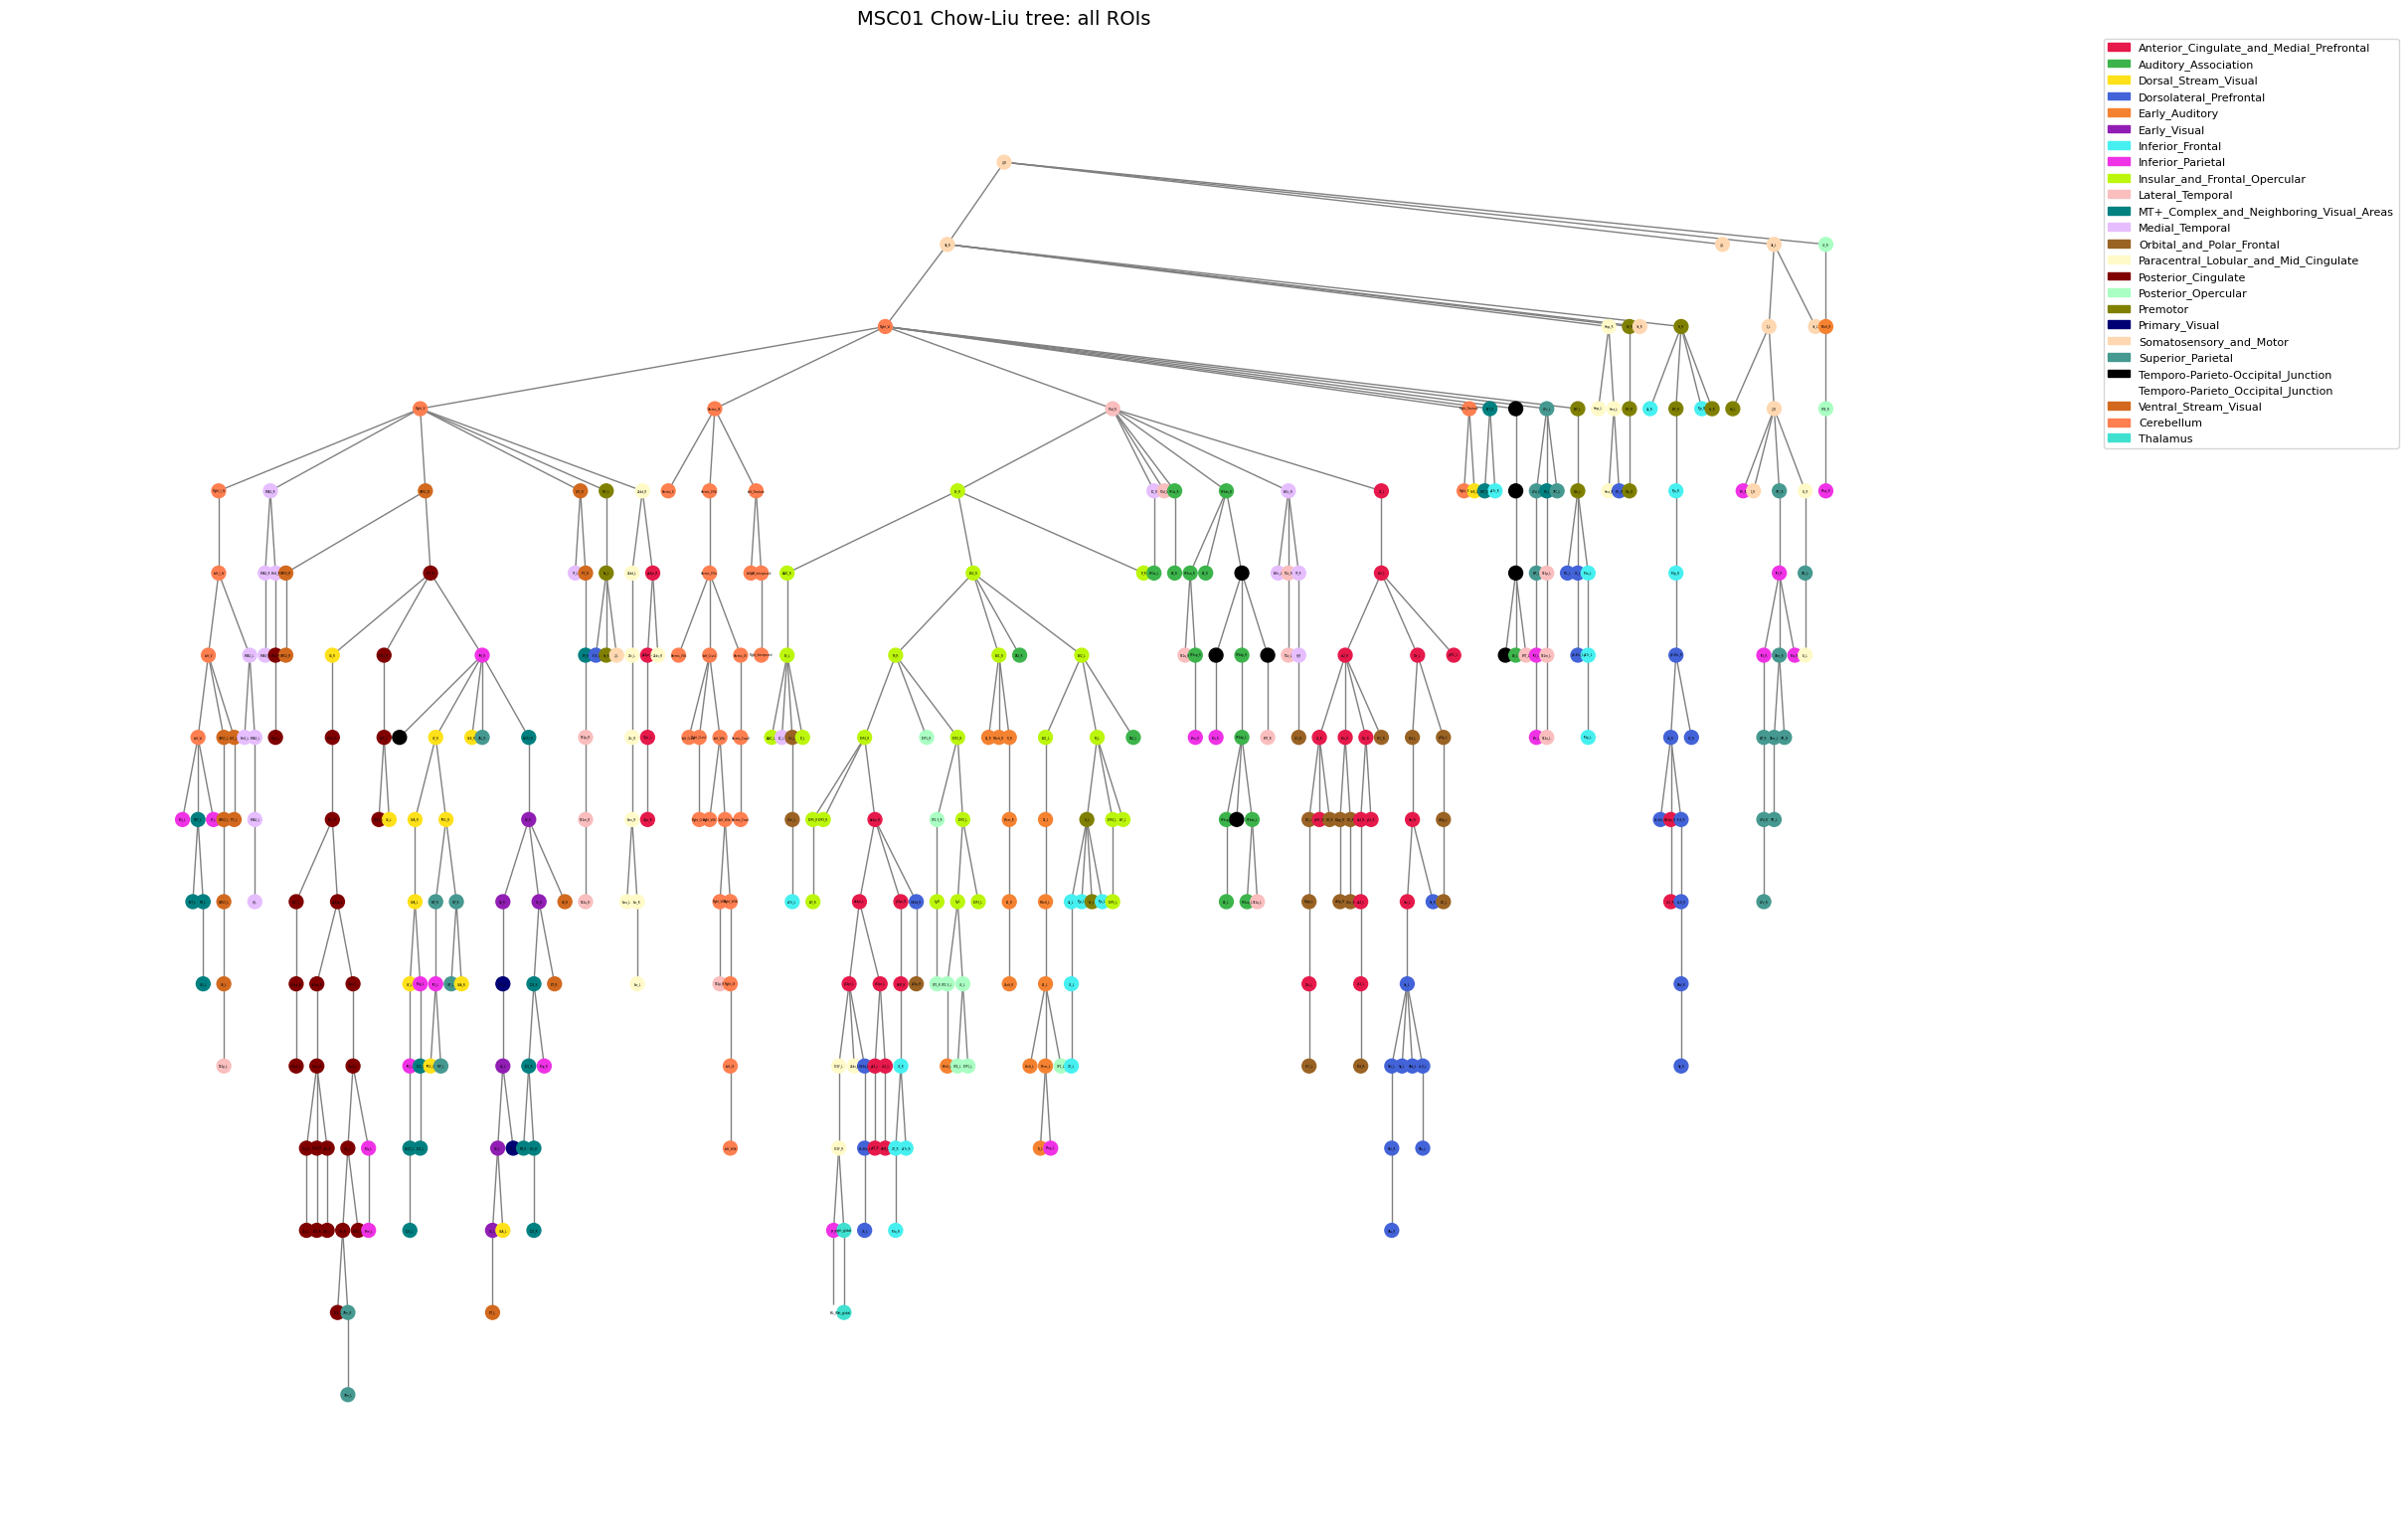

In [105]:
subject = 'MSC01'
# root = list(selective_cl_trees[subject].nodes)[0]
root = 7
node_size = 100
font_size = 2
figsize=(20, 15)
tree, pos, network_names, colors = draw_hierarchical_tree(cl_trees[subject], atlas_name = 'glasser360_SUIT_Thalamus', root=root,  title=f"{subject} Chow-Liu tree: all ROIs", region_names=all_labels, node_size=node_size, font_size=font_size, figsize=figsize)

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum']


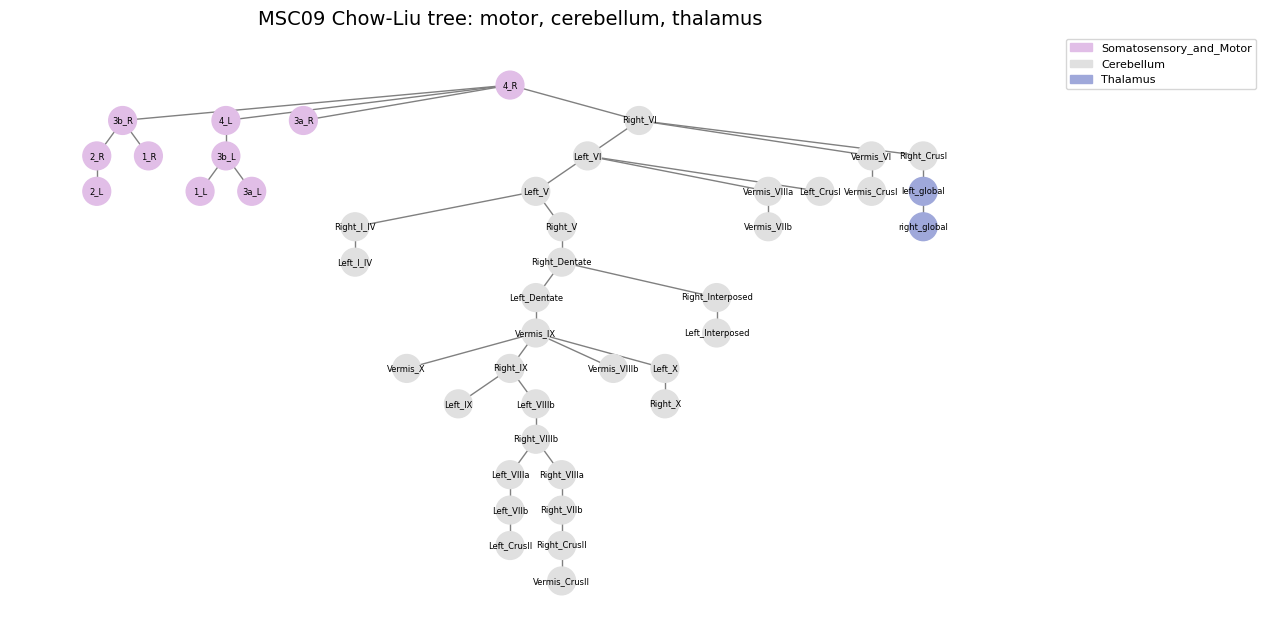

In [267]:
subject = 'MSC09'
# root = list(selective_cl_trees[subject].nodes)[0]
root = 7
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees[subject], atlas_name = 'glasser360_SUIT_Thalamus', root=root, selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], title=f"{subject} Chow-Liu tree: motor, cerebellum, thalamus", region_names=all_labels)

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

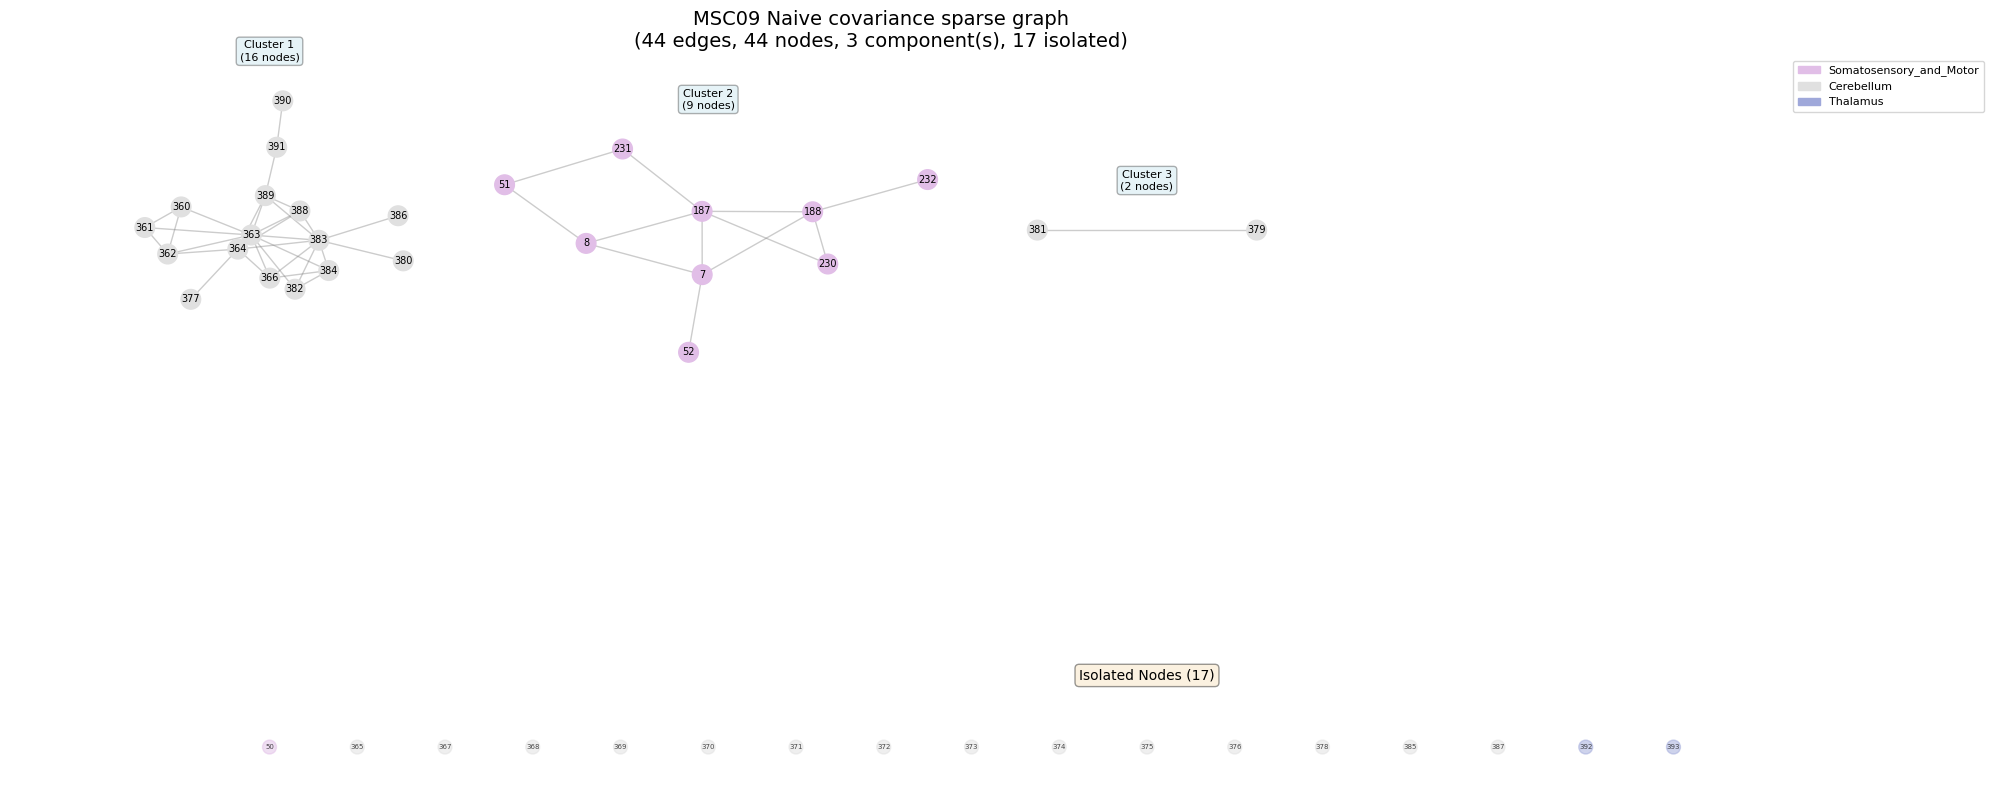

Graph has 44 edges out of 946 possible edges
Graph density: 0.0465


In [107]:
subject = 'MSC09'
cov_graph, selected_nodes = sparse_covariance_top_edges(cov[100][subject].numpy(), selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])
tree, network_names, colors = draw_covariance_graph(cov_graph, atlas_name = 'glasser360_SUIT_Thalamus', selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], root=8, title=f'{subject} Naive covariance sparse graph', layout='kamada')

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor']


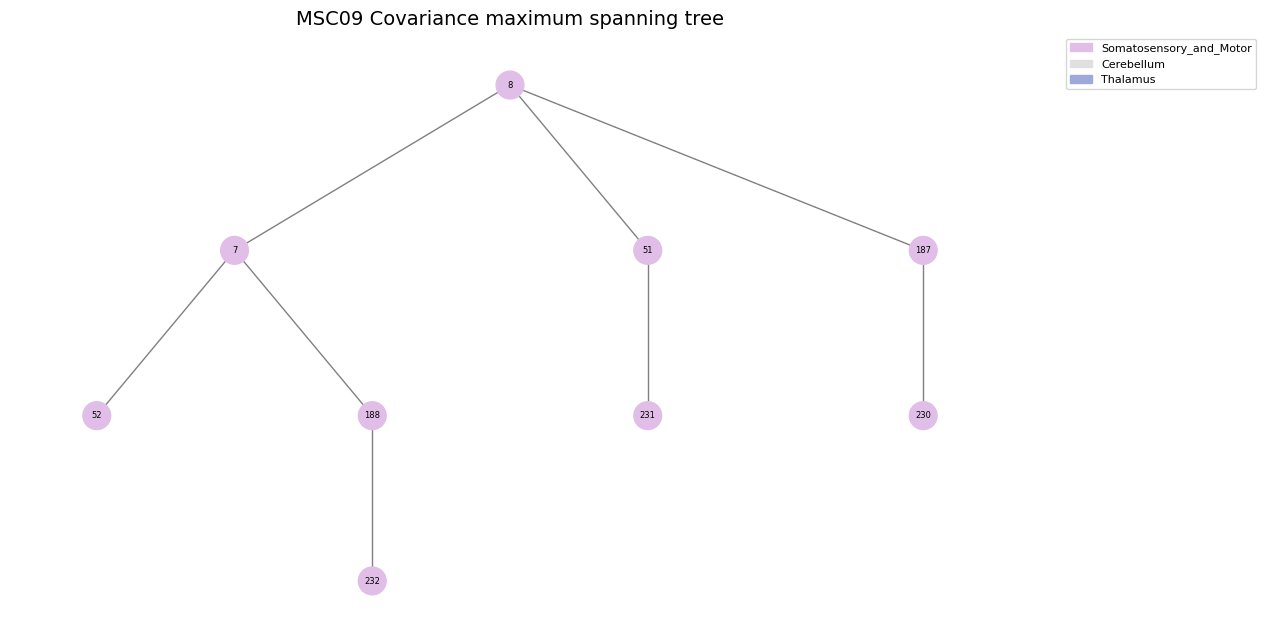

In [108]:
tree, network_names, colors, _ = draw_hierarchical_tree(cov_graph, atlas_name = 'glasser360_SUIT_Thalamus', selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], root=8, title=f'{subject} Covariance maximum spanning tree')

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Cerebellum']


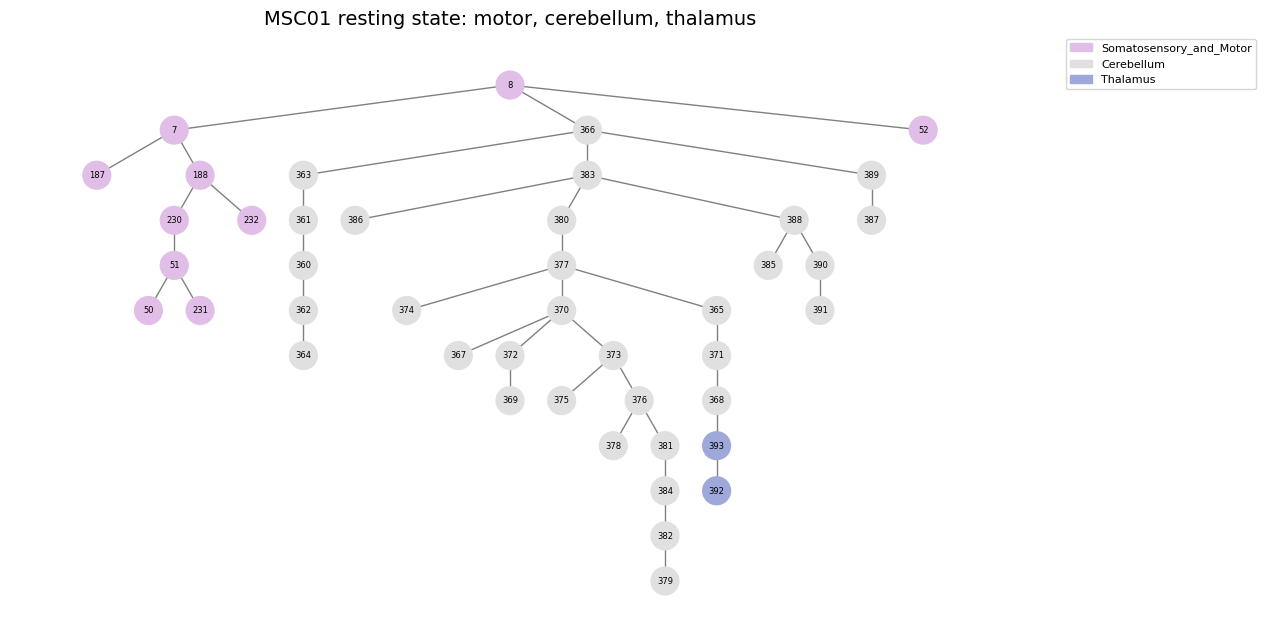

In [109]:
subject = 'MSC01'
# root = list(selective_cl_trees[subject].nodes)[0]
root = 8
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees[subject], atlas_name = 'glasser360_SUIT_Thalamus', root=root, selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], title=f"{subject} resting state: motor, cerebellum, thalamus")

In [110]:
len(selective_cl_trees['MSC01'])

44

In [ ]:


# Suppose G is your participant's Chow-Liu tree as a weighted NetworkX graph
# G = nx.Graph()  # ... Build/load your graph here

def plot_degree_strength(G, participant_id=None):
    degrees = dict(G.degree())
    strengths = dict(G.degree(weight='weight'))
    
    # Plot degree distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    degree_values = list(degrees.values())
    plt.hist(degree_values, bins=np.arange(0.5, max(degree_values)+1.5, 1), color='cornflowerblue', edgecolor='k')
    plt.xlabel('Degree')
    plt.ylabel('Number of Nodes')
    plt.title(f'Degree Distribution{f" (Participant {participant_id})" if participant_id else ""}')
    
    # Plot strength distribution
    plt.subplot(1, 2, 2)
    strength_values = list(strengths.values())
    plt.hist(strength_values, bins=15, color='salmon', edgecolor='k')
    plt.xlabel('Strength (sum of edge weights)')
    plt.ylabel('Number of Nodes')
    plt.title(f'Strength Distribution{f" (Participant {participant_id})" if participant_id else ""}')
    
    plt.tight_layout()
    plt.show()
    return degrees, strengths

# Usage example:
# degrees, strengths = plot_degree_strength(G, participant_id=1)


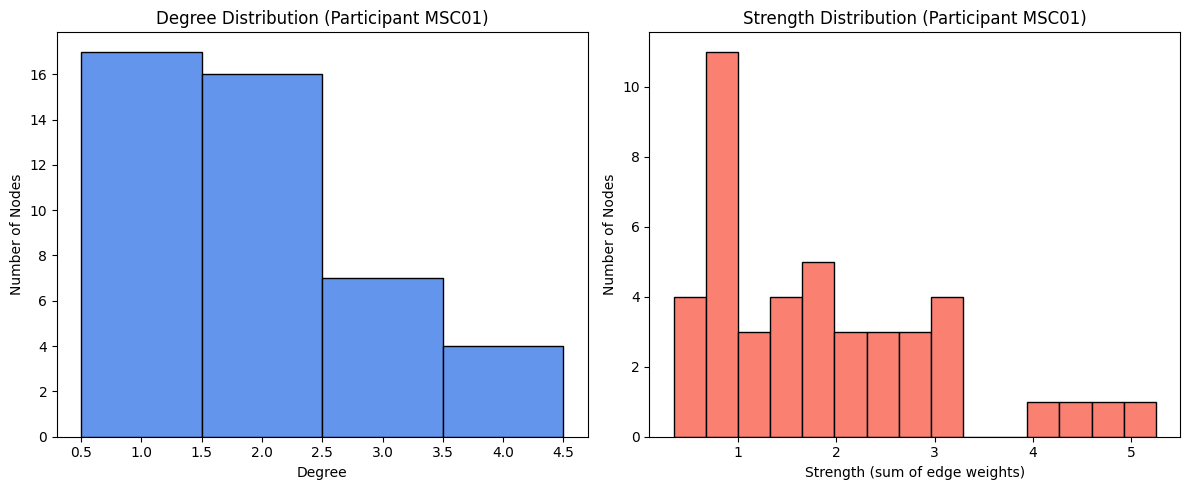

In [175]:
degrees1, strengths1 = plot_degree_strength(selective_cl_trees['MSC01'], participant_id='MSC01')

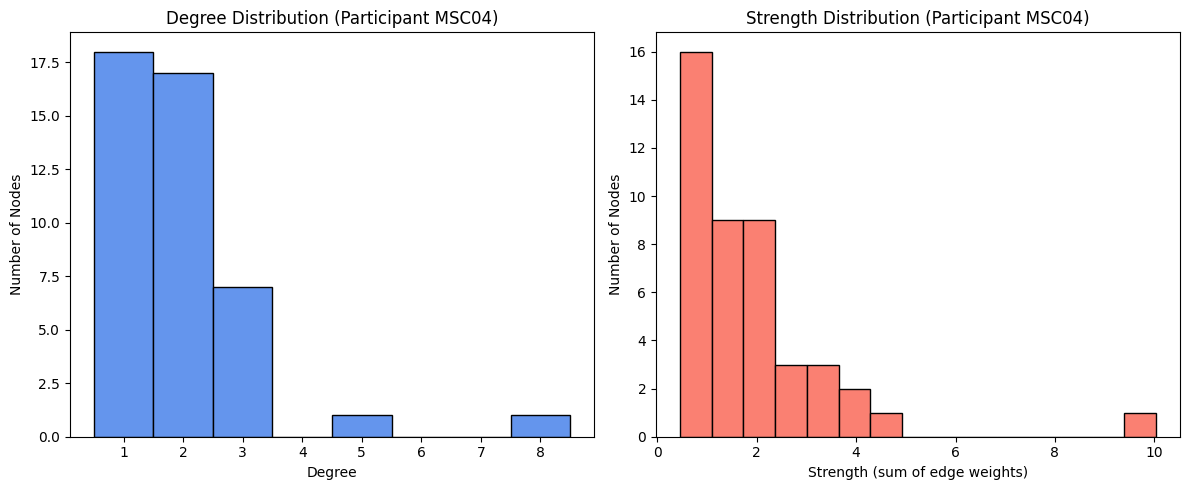

In [176]:
degrees2, strengths2 = plot_degree_strength(selective_cl_trees['MSC04'], participant_id='MSC04')

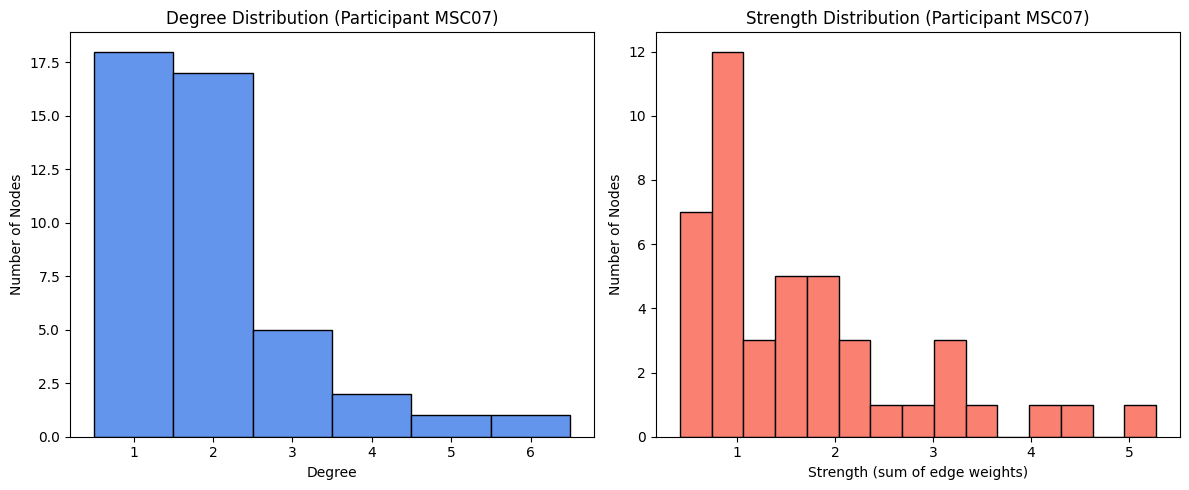

In [177]:
degrees3, strengths3 = plot_degree_strength(selective_cl_trees['MSC07'], participant_id='MSC07')

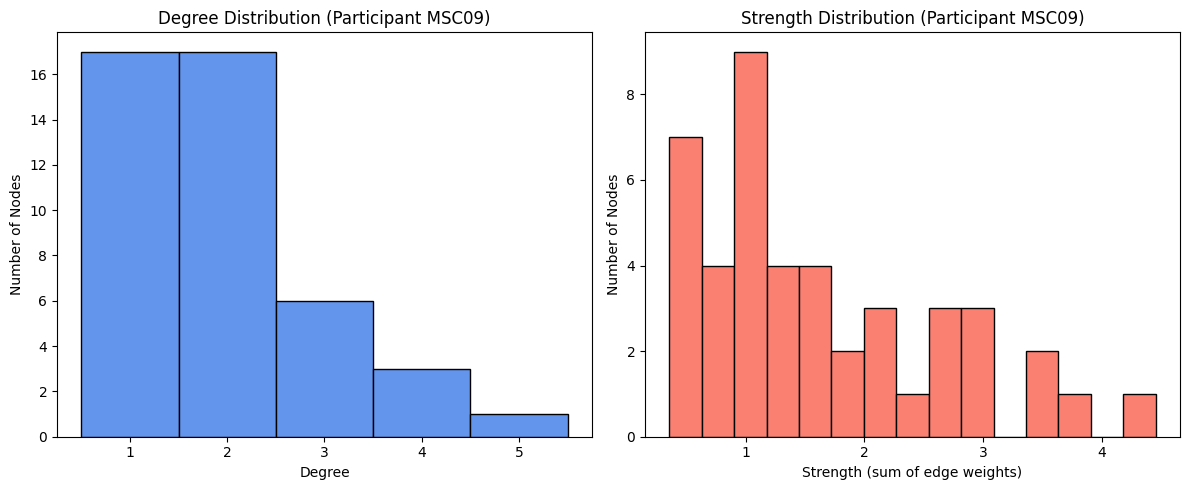

In [178]:
degrees4, strengths4 = plot_degree_strength(selective_cl_trees['MSC09'], participant_id='MSC09')

In [206]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# List of participant graphs: G_list = [G1, G2, G3, G4]
def summarize_graph_metrics(G_list):
    metrics = {
        'mean_degree': [],
        'mean_strength': [],
        'clustering': [],
        'char_path_length': []
    }
    degree_dists = []
    strength_dists = []

    for G in G_list:
        degrees = np.array(list(dict(G.degree()).values()))
        strengths = np.array(list(dict(G.degree(weight='weight')).values()))
        degree_dists.append(degrees)
        strength_dists.append(strengths)
        metrics['mean_degree'].append(degrees.mean())
        metrics['mean_strength'].append(strengths.mean())
        metrics['clustering'].append(nx.average_clustering(G, weight='weight'))
        try:
            metrics['char_path_length'].append(nx.average_shortest_path_length(G, weight='weight'))
        except nx.NetworkXError:
            metrics['char_path_length'].append(np.nan)  # not connected

    # Group averages for metrics
    avg_metrics = {m: np.nanmean(metrics[m]) for m in metrics}
    metrics['mean_degree'].append(avg_metrics['mean_degree'])
    metrics['mean_strength'].append(avg_metrics['mean_strength'])
    metrics['clustering'].append(avg_metrics['clustering'])
    metrics['char_path_length'].append(avg_metrics['char_path_length'])
    participant_labels = ['MSC01', 'MSC04', 'MSC07', 'MSC09', 'Group Average']
    return metrics, degree_dists, strength_dists, participant_labels

def plot_network_metrics_comparison(G_list):
    metrics, degree_dists, strength_dists, labels = summarize_graph_metrics(G_list)

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Chow-Liu Tree Network Metrics: Participants & Group Average", fontsize=16)

    # Panel A: Comparison Barplots
    bar_width = 0.4
    x_pos = np.arange(len(labels))
    color_cycle = sns.color_palette("tab10", n_colors=len(labels))

    axs[0, 0].bar(x_pos, metrics['mean_degree'], color=color_cycle)
    axs[0, 0].set_xticks(x_pos)
    axs[0, 0].set_xticklabels(labels)
    axs[0, 0].set_ylabel('Mean Degree')
    axs[0, 0].set_title('Mean Degree per Participant')
    
    axs[1, 0].bar(x_pos, metrics['mean_strength'], color=color_cycle)
    axs[1, 0].set_xticks(x_pos)
    axs[1, 0].set_xticklabels(labels)
    axs[1, 0].set_ylabel('Mean Strength')
    axs[1, 0].set_title('Mean Strength per Participant')

    # Panel B: Degree Distribution KDEs
    for i, d in enumerate(degree_dists):
        sns.kdeplot(d, ax=axs[0, 1], label=labels[i], lw=2)
    axs[0, 1].set_title('Degree Distributions')
    axs[0, 1].set_xlabel('Degree')
    axs[0, 1].set_ylabel('Density')
    axs[0, 1].legend()

    # Panel C: Strength Distribution KDEs
    for i, s in enumerate(strength_dists):
        sns.kdeplot(s, ax=axs[1, 1], label=labels[i], lw=2)
    axs[1, 1].set_title('Strength Distributions')
    axs[1, 1].set_xlabel('Strength')
    axs[1, 1].set_ylabel('Density')
    axs[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Example usage:
# plot_network_metrics_comparison([G1, G2, G3, G4])


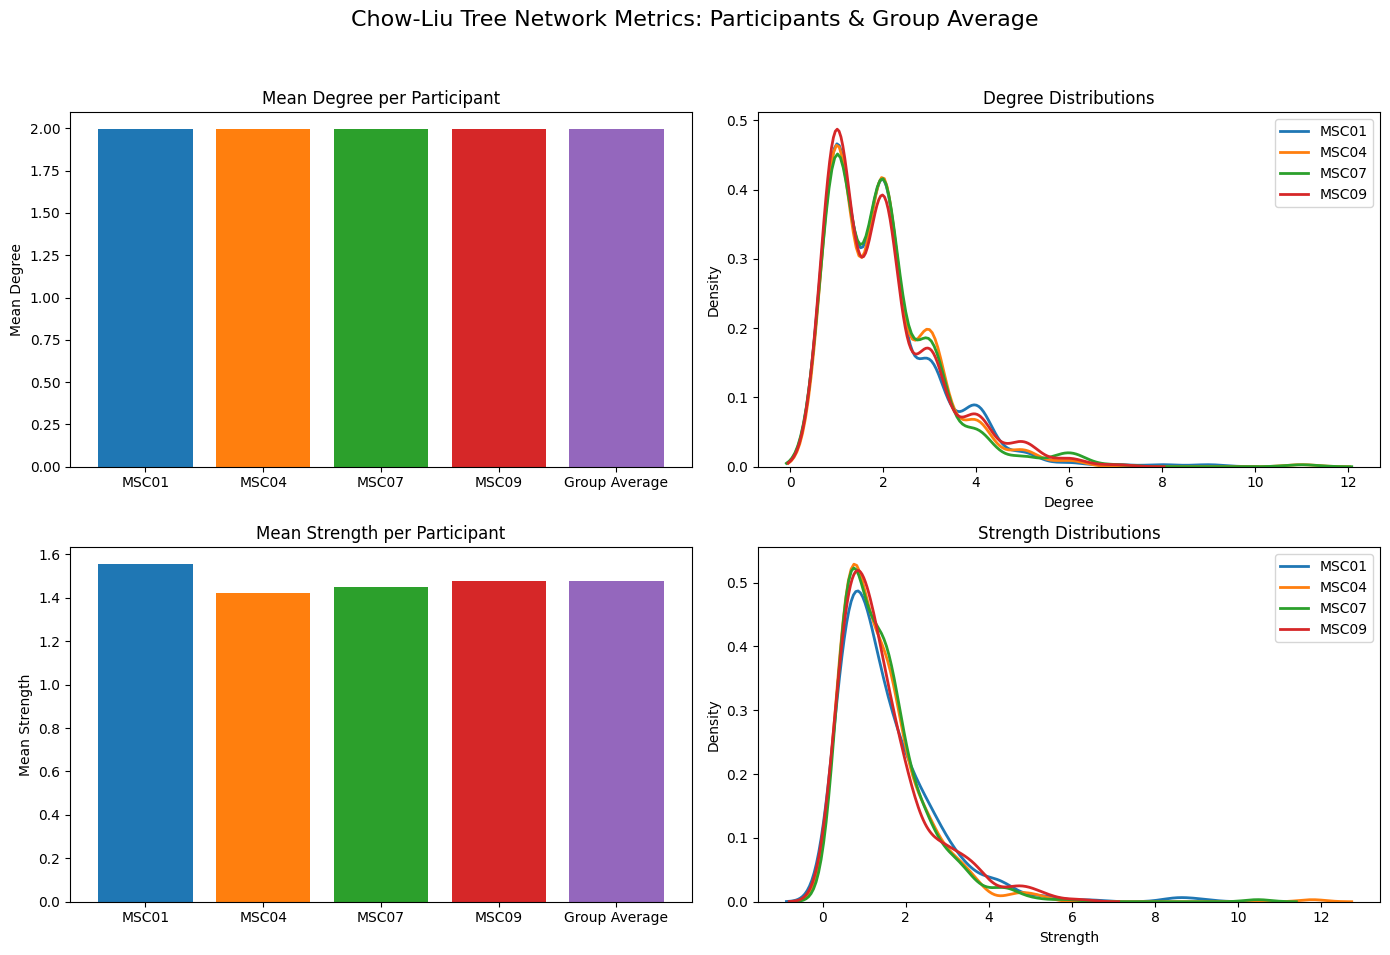

In [207]:
plot_network_metrics_comparison([cl_trees['MSC01'], cl_trees['MSC04'], cl_trees['MSC07'], cl_trees['MSC09']])

In [257]:
mi_G = []
cov_G = []

mi_threshold = 1.2
cov_threshold = 0.94

for participant in subjects:
    # Build MI graph
    mat_mi = np.array(mi_gst[100][participant])
    G_mi = nx.Graph()
    for i in range(mat_mi.shape[0]):
        for j in range(i + 1, mat_mi.shape[1]):
            if mat_mi[i, j] > mi_threshold:
                G_mi.add_edge(i, j, weight=mat_mi[i, j])
    mi_G.append(G_mi)

    # Build Covariance graph
    mat_cov = np.array(cov[100][participant])
    G_cov = nx.Graph()
    for i in range(mat_cov.shape[0]):
        for j in range(i + 1, mat_cov.shape[1]):
            if mat_cov[i, j] > cov_threshold:
                G_cov.add_edge(i, j, weight=mat_cov[i, j])
    cov_G.append(G_cov)


In [204]:
mi_G[0].edges()

EdgeView([(1, 156), (105, 108), (105, 166), (108, 107), (109, 111), (125, 152), (125, 153), (125, 305), (125, 361), (125, 363), (125, 366), (152, 153), (152, 159), (152, 361), (152, 363), (152, 366), (153, 159), (153, 363), (153, 366), (305, 298), (305, 306), (305, 360), (305, 361), (305, 362), (361, 360), (361, 362), (361, 363), (361, 366), (363, 360), (363, 362), (363, 364), (363, 366), (366, 362), (366, 364), (366, 383), (140, 145), (195, 325), (282, 346), (360, 362), (362, 364), (383, 380), (383, 386), (383, 388), (367, 370)])

/var/folders/cf/4z622f6j29d4qx7rzj6l433m0000gp/T/ipykernel_5795/4267429032.py:31: RuntimeWarning: Mean of empty slice
  avg_metrics = {m: np.nanmean(metrics[m]) for m in metrics}


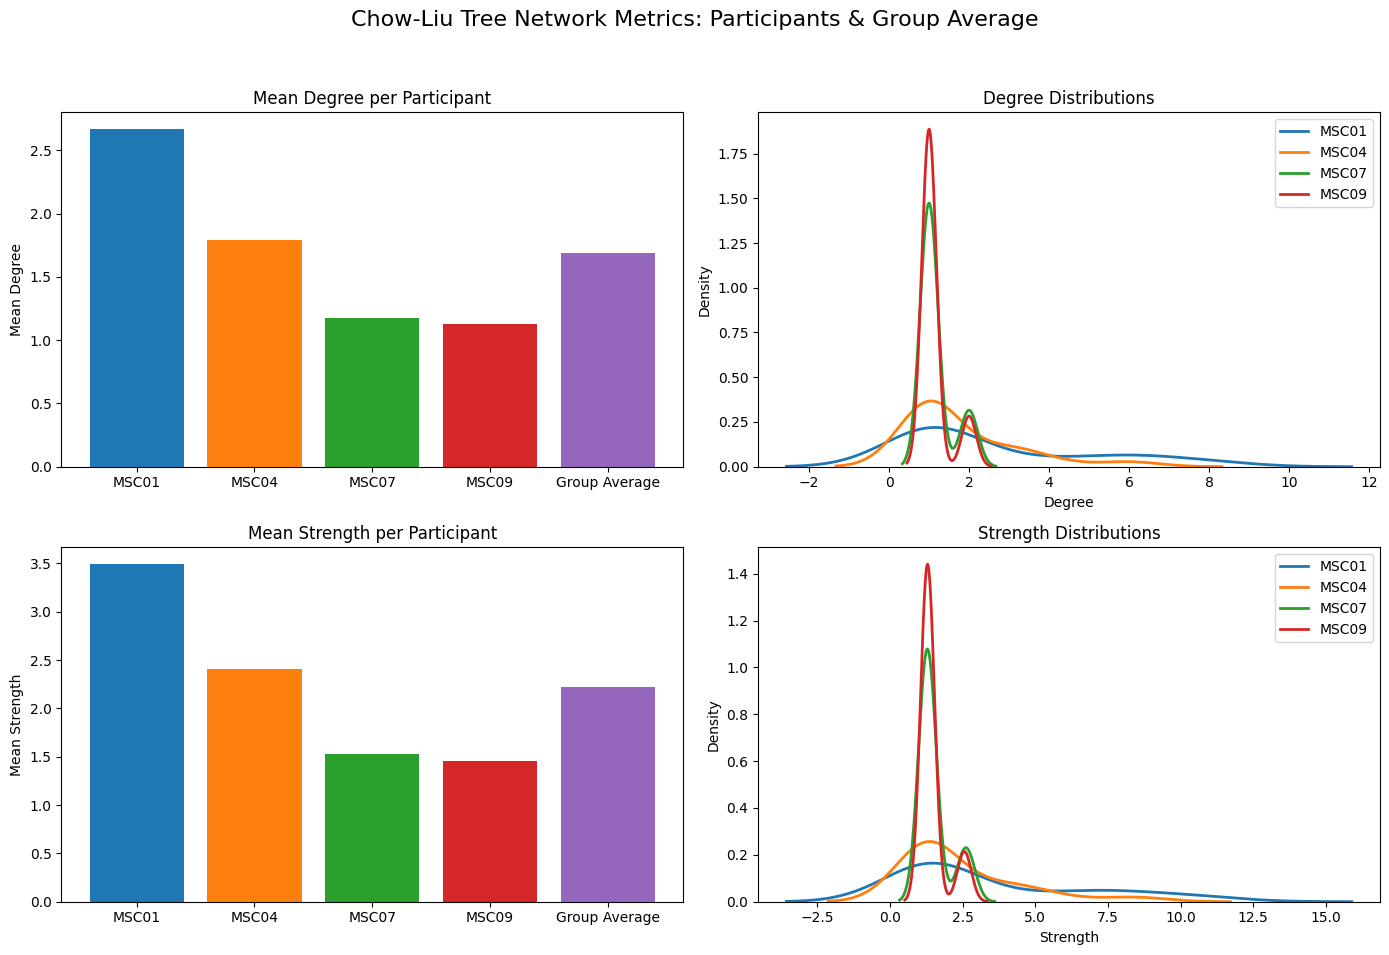

In [213]:
plot_network_metrics_comparison(mi_G)

/var/folders/cf/4z622f6j29d4qx7rzj6l433m0000gp/T/ipykernel_5795/4267429032.py:31: RuntimeWarning: Mean of empty slice
  avg_metrics = {m: np.nanmean(metrics[m]) for m in metrics}


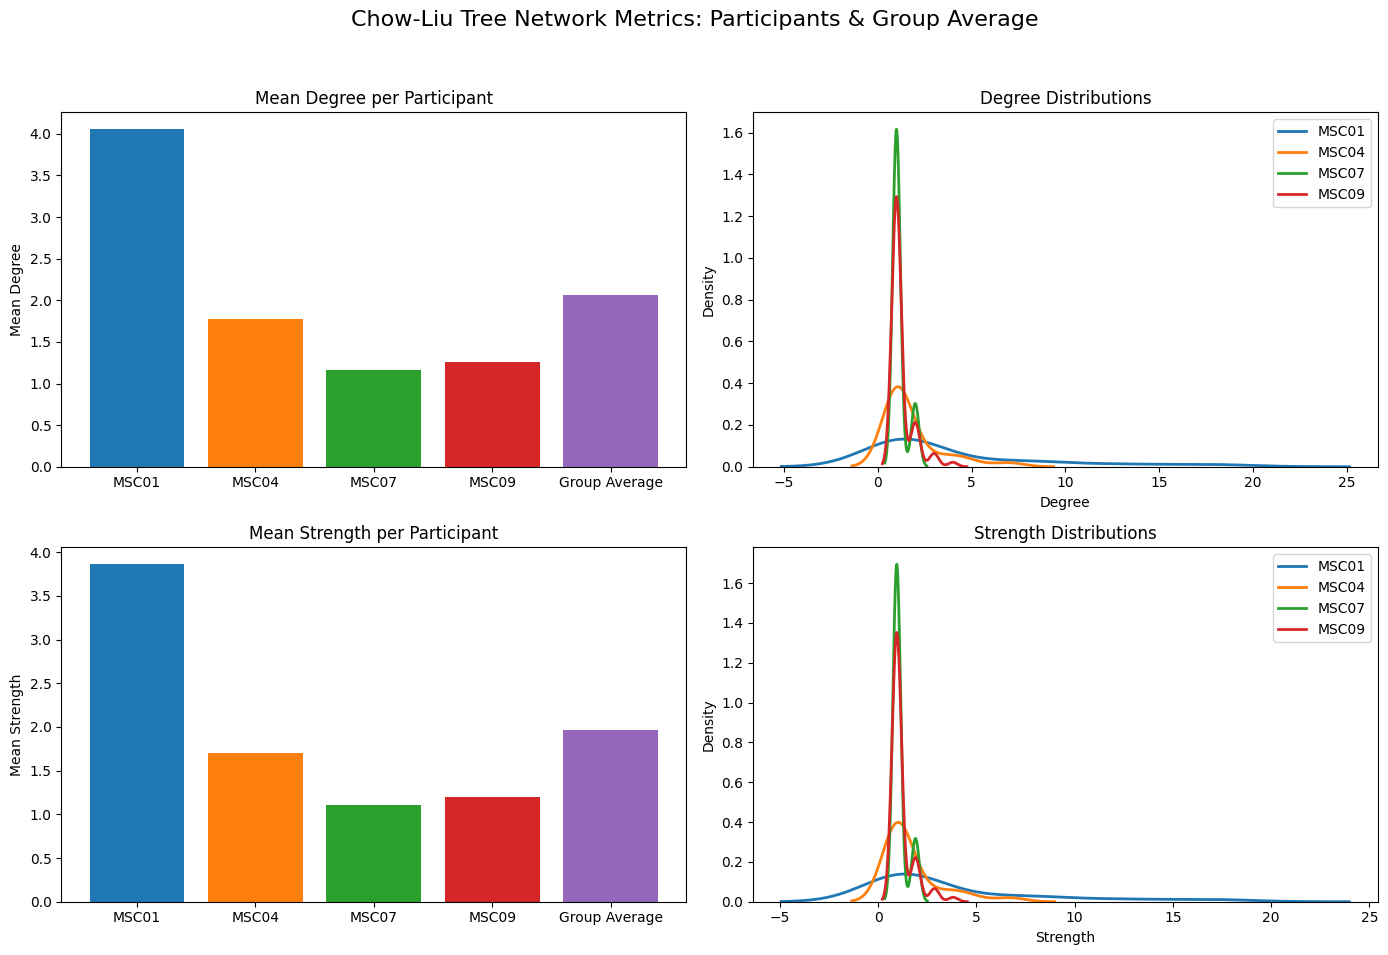

In [259]:
plot_network_metrics_comparison(cov_G)

In [215]:
import networkx as nx
import numpy as np
import pandas as pd

def compute_graph_metrics(G):
    # Safe get, return np.nan if the metric cannot be computed
    def safe_metric(func, *args, **kwargs):
        try:
            return func(*args, **kwargs)
        except Exception:
            return np.nan

    if G.number_of_nodes() == 0:
        return {  # All nan for empty graph
            'num_nodes': 0,
            'num_edges': 0,
            'mean_degree': np.nan,
            'mean_strength': np.nan,
            'clustering': np.nan,
            'char_path': np.nan,
            'global_eff': np.nan,
            'local_eff': np.nan,
            'assortativity': np.nan,
            'density': np.nan,
            'transitivity': np.nan
        }

    degrees = np.array(list(dict(G.degree()).values()))
    strengths = np.array(list(dict(G.degree(weight='weight')).values()))
    return {
        'num_nodes': G.number_of_nodes(),
        'num_edges': G.number_of_edges(),
        'mean_degree': degrees.mean() if len(degrees) else np.nan,
        'mean_strength': strengths.mean() if len(strengths) else np.nan,
        'clustering': safe_metric(nx.average_clustering, G, weight='weight'),
        'char_path': safe_metric(nx.average_shortest_path_length, G, weight='weight') if nx.is_connected(G) else np.nan,
        'global_eff': safe_metric(nx.global_efficiency, G),
        'local_eff': safe_metric(nx.local_efficiency, G),
        'assortativity': safe_metric(nx.degree_assortativity_coefficient, G),
        'density': safe_metric(nx.density, G),
        'transitivity': safe_metric(nx.transitivity, G)
    }

def metrics_table(G_list, participant_labels=None):
    rows = []
    for i, G in enumerate(G_list):
        row = compute_graph_metrics(G)
        rows.append(row)
    df = pd.DataFrame(rows)
    if participant_labels:
        df.index = participant_labels
    # Add row for group mean (excluding non-numeric columns)
    df.loc['Mean'] = df.mean(numeric_only=True)
    return df

# Usage:
# G_list = [G1, G2, G3, G4]  # List of participant graphs
# labels = [f"Participant {i+1}" for i in range(len(G_list))]
# df = metrics_table(G_list, labels)
# print(df.to_markdown())         # publication-style for markdown
# print(df.round(2).to_latex())   # LaTeX for journal
# df.to_csv("network_metrics.csv")# CSV for sharing


In [219]:
cl1 = compute_graph_metrics(selective_cl_trees['MSC01'])

In [220]:
cl2 = compute_graph_metrics(selective_cl_trees['MSC04'])

In [221]:
cl3 = compute_graph_metrics(selective_cl_trees['MSC07'])

In [222]:
cl4 = compute_graph_metrics(selective_cl_trees['MSC09'])

In [226]:
mean = {}
for key, value in cl1.items():
    if isinstance(value, (int, float)):
        mean[key] = np.mean([cl1[key], cl2[key], cl3[key], cl4[key]])
    else:
        mean[key] = np.mean(np.array([cl1[key], cl2[key], cl3[key], cl4[key]], dtype=np.float64))

In [227]:
mean

{'num_nodes': 44.0,
 'num_edges': 43.0,
 'mean_degree': 1.9545454545454546,
 'mean_strength': 1.7770549356937408,
 'clustering': 0.0,
 'char_path': 5.918307662010193,
 'global_eff': 0.23704041652291177,
 'local_eff': 0.0,
 'assortativity': -0.16098408799326588,
 'density': 0.045454545454545456,
 'transitivity': 0.0}

In [228]:
mi1, mi2, mi3, mi4 = compute_graph_metrics(cl_trees['MSC01']), compute_graph_metrics(cl_trees['MSC04']), compute_graph_metrics(cl_trees['MSC07']), compute_graph_metrics(cl_trees['MSC09'])

In [231]:
mi_mean = {}
for key, value in mi1.items():
    if isinstance(value, (int, float)):
        mi_mean[key] = np.mean([mi1[key], mi2[key], mi3[key], mi4[key]])
    else:
        mi_mean[key] = np.mean(np.array([mi1[key], mi2[key], mi3[key], mi4[key]], dtype=np.float64))

In [232]:
mi_mean

{'num_nodes': 394.0,
 'num_edges': 393.0,
 'mean_degree': 1.9949238578680204,
 'mean_strength': 1.475118637084961,
 'clustering': 0.0,
 'char_path': 11.281455278396606,
 'global_eff': 0.10257633670849448,
 'local_eff': 0.0,
 'assortativity': -0.040972156268516365,
 'density': 0.005076142131979695,
 'transitivity': 0.0}

In [251]:
cov1, cov2, cov3, cov4 = compute_graph_metrics(cov_G[0]), compute_graph_metrics(cov_G[1]), compute_graph_metrics(cov_G[2]), compute_graph_metrics(cov_G[3])

In [255]:
cov_mean = {}
for key, value in cov1.items():
    if isinstance(value, (int, float)):
        cov_mean[key] = np.mean([cov1[key], cov2[key], cov3[key], cov4[key]])
    else:
        cov_mean[key] = np.mean(np.array([cov1[key], cov2[key], cov3[key], cov4[key]], dtype=np.float64))

In [258]:
cov_mean

{'num_nodes': 30.0,
 'num_edges': 29.0,
 'mean_degree': 1.7452380952380953,
 'mean_strength': 1.677936155428715,
 'clustering': 0.13142979783046727,
 'char_path': nan,
 'global_eff': 0.1134158514593295,
 'local_eff': 0.14348816441207746,
 'assortativity': 0.3562233749326288,
 'density': 0.07549950049950051,
 'transitivity': 0.43762768130745655}

In [ ]:
# Plot degree distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
degree_values = list(degrees.values())
plt.hist(degree_values, bins=np.arange(0.5, max(degree_values)+1.5, 1), color='cornflowerblue', edgecolor='k')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title(f'Degree Distribution{f" (Participant {participant_id})" if participant_id else ""}')

# Plot strength distribution
plt.subplot(1, 2, 2)
strength_values = list(strengths.values())
plt.hist(strength_values, bins=15, color='salmon', edgecolor='k')
plt.xlabel('Strength (sum of edge weights)')
plt.ylabel('Number of Nodes')
plt.title(f'Strength Distribution{f" (Participant {participant_id})" if participant_id else ""}')

plt.tight_layout()
plt.show()
return degrees, strengths


## **plotting circuits**

In [ ]:
from nilearn.plotting import plot_roi, show

## **Consistency score**

In [41]:
cov_graphs = {}

for subject in subjects:
    cov_graphs[subject], selected_nodes = sparse_covariance_top_edges(cov[100][subject].numpy(), selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

In [43]:
len(cov_graphs['MSC01'])

123

In [51]:
from scipy.linalg import eigh

def spectral_distance(G1, G2, k=10):
    """
    Compare graphs using Laplacian eigenvalues.
    Very fast for large graphs.
    """
    # Get Laplacian matrices
    L1 = nx.laplacian_matrix(G1).toarray()
    L2 = nx.laplacian_matrix(G2).toarray()
    
    # Get k smallest eigenvalues
    evals1 = np.sort(eigh(L1, eigvals_only=True)[:k])
    evals2 = np.sort(eigh(L2, eigvals_only=True)[:k])
    
    # Euclidean distance between eigenvalue vectors
    return np.linalg.norm(evals1 - evals2)

In [58]:
cl_graph_dists = {}
cl_graph_dists['spectral dist'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = selective_cl_trees[subjects[i]]
        G2 = selective_cl_trees[subjects[j]]
        cl_graph_dists['spectral dist'][i, j] = spectral_distance(G1, G2)

comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09


In [61]:
cov_graph_dists = {}
cov_graph_dists['spectral dist'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = cov_graphs[subjects[i]]
        G2 = cov_graphs[subjects[j]]
        cov_graph_dists['spectral dist'][i, j] = spectral_distance(G1, G2)

comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09


In [62]:
cov_graph_dists['spectral dist']

array([[0.00000000e+00, 2.51859683e-06, 2.08813435e-06, 3.30559146e-06],
       [0.00000000e+00, 0.00000000e+00, 1.40346128e-06, 9.30624878e-07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.67087217e-06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [63]:
cl_graph_dists['spectral dist']

array([[0.        , 0.00993351, 0.02440318, 0.02493644],
       [0.        , 0.        , 0.01715287, 0.02231056],
       [0.        , 0.        , 0.        , 0.01540633],
       [0.        , 0.        , 0.        , 0.        ]])

In [64]:
def deltacon(G1, G2, exact=False):
    """
    Fast similarity measure based on node affinities.
    One of the best for large graphs.
    """
    # Get adjacency matrices (need same node set)
    nodes = sorted(set(G1.nodes()) | set(G2.nodes()))
    A1 = nx.to_numpy_array(G1, nodelist=nodes)
    A2 = nx.to_numpy_array(G2, nodelist=nodes)
    
    n = len(nodes)
    
    # Fast belief propagation affinity
    # S = (I + eps*D)^-1 * (I + eps*A)
    eps = 1.0 / (1.0 + np.max([A1.sum(), A2.sum()]))
    
    I = np.eye(n)
    D1 = np.diag(A1.sum(axis=1))
    D2 = np.diag(A2.sum(axis=1))
    
    S1 = np.linalg.inv(I + eps * D1) @ (I + eps * A1)
    S2 = np.linalg.inv(I + eps * D2) @ (I + eps * A2)
    
    # Root Euclidean Distance
    distance = np.sqrt(np.sum((np.sqrt(S1) - np.sqrt(S2)) ** 2))
    
    # Normalize to [0, 1]
    similarity = 1.0 / (1.0 + distance)
    
    return 1 - similarity  # Return distance

In [ ]:
cl_graph_dists = {}
cl_graph_dists['deltacon'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = selective_cl_trees[subjects[i]]
        G2 = selective_cl_trees[subjects[j]]
        cl_graph_dists['deltacon'][i, j] = deltacon(G1, G2)


cov_graph_dists = {}
cov_graph_dists['deltacon'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = cov_graphs[subjects[i]]
        G2 = cov_graphs[subjects[j]]
        cov_graph_dists['deltacon'][i, j] = deltacon(G1, G2)

comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09
comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09


In [68]:
print(cl_graph_dists['deltacon'])
print(cov_graph_dists['deltacon'])

[[0.         0.45096027 0.47333767 0.46722283]
 [0.         0.         0.46088948 0.43884166]
 [0.         0.         0.         0.43982375]
 [0.         0.         0.         0.        ]]
[[0.         0.53354849 0.54067893 0.49693246]
 [0.         0.         0.48943917 0.50740005]
 [0.         0.         0.         0.50631385]
 [0.         0.         0.         0.        ]]


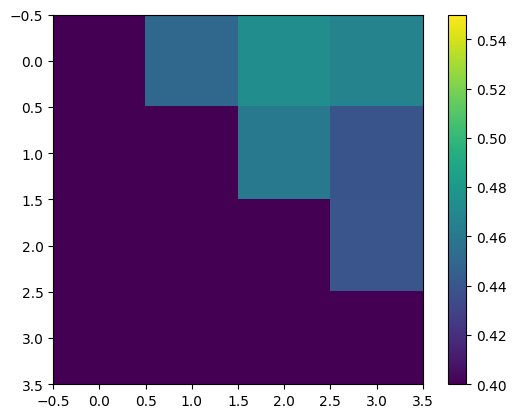

In [72]:
plt.imshow(cl_graph_dists['deltacon'], vmin=0.4, vmax=0.55)
plt.colorbar()

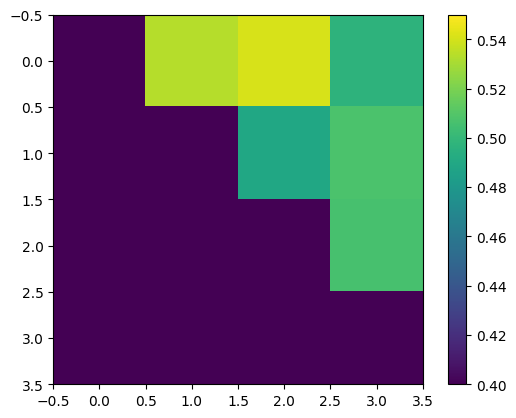

In [79]:
plt.imshow(cov_graph_dists['deltacon'], vmin=0.4, vmax=0.55)
plt.colorbar()

In [73]:
nonzero_cl_graph_dists = cl_graph_dists['deltacon'][cl_graph_dists['deltacon'] > 0]
nonzero_cov_graph_dists = cov_graph_dists['deltacon'][cov_graph_dists['deltacon'] > 0]

<BarContainer object of 2 artists>

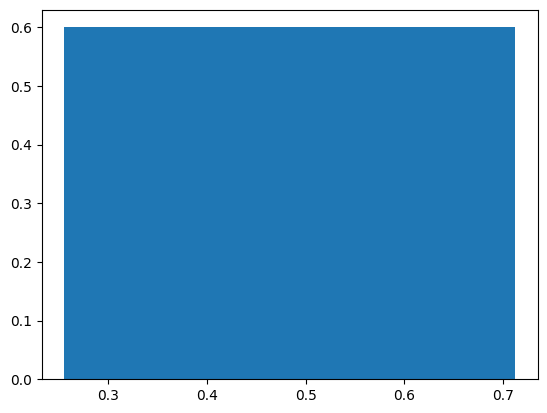

In [78]:
plt.bar((np.mean(nonzero_cl_graph_dists), np.mean(nonzero_cov_graph_dists)), width=0.4, height=0.6, label=['Chow-Liu', 'Covariance'])

<BarContainer object of 6 artists>

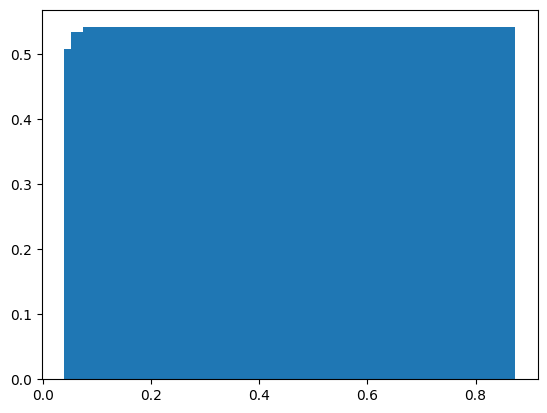

In [74]:
# Pairwise comparisons
print("\nPairwise comparisons (Mann-Whitney U):")
for i in range(len(set_names)):
    for j in range(i + 1, len(set_names)):
        u_stat, p_val = stats.mannwhitneyu(
            all_distances[set_names[i]], 
            all_distances[set_names[j]]
        )
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f"  {set_names[i]} vs {set_names[j]}: p = {p_val:.4e} {sig}")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors_multi = ['#E1BEE7', '#BA68C8', '#9C27B0', '#7B1FA2', '#4A148C'][:len(set_names)]

bars = ax.bar(set_names, all_means, yerr=all_sems, capsize=10,
                color=colors_multi, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Mean Distance', fontsize=12, fontweight='bold')
ax.set_title(title, fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

# Add sample sizes
for i, (name, distances) in enumerate(all_distances.items()):
    ax.text(i, -max(all_means)*0.05, f'n={len(distances)}', 
            ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

return all_distances